# Deep Learning for the HJB Equation — Hard-BC + Log-of-Affine Ansatz (log utility, $\gamma = 1$)

## Master's Thesis — Cecilia Trojani (UZH / ETH, 2025–2026)

---

This notebook solves the homogeneous Blanchard OLG HJB equation under log preferences
$u(c) = \log c$ (the $\gamma = 1$ specialisation of CRRA) using a physics-informed
neural network (PINN) with a **hard boundary condition** built into the architecture
and **NN-direct policies** trained alongside the value function (Scheidegger-style).

### Overview

- **Architecture.** A log-of-affine trial solution
  $$
  \widehat V(w, y) \;=\; \frac{1}{\delta}\,
                       \log\!\Big(w + y \cdot \text{softplus}\bigl(\mathrm{NN}_\phi(w, y)\bigr)\Big)
                       \;+\; K_{cf}
  $$
  exactly matches the closed-form structure
  $V^{\star} = \tfrac{1}{\delta}\log(w + \varphi_e\, y) + K^{\star}$.
  Because $y_{\min} = 0$, the trial solution reduces to
  $V_{BC}(w) = \tfrac{1}{\delta}\log w + K_{cf}$
  at the boundary $y = 0$ for any network output, so the homogeneous boundary
  condition is satisfied **architecturally** without any penalty term.
  Policies are learned by additional output heads:
  $c = c_{BC}(w) + y\cdot \mathrm{NN}_c(w, y)$,
  $\pi = \pi_{BC}(w) + y\cdot \mathrm{NN}_\pi(w, y)$.

- **Training pipeline (two phases, no warm-up).**
  - *Phase 1.* Adam in FP32, 35,000 epochs, learning rate $10^{-4}$ constant
    throughout (a `MultiStepLR` is registered but never fires). Starts from
    a random Xavier initialisation.
  - *Phase 2.* L-BFGS in FP64 with strong-Wolfe line search on a
    residual-weighted frozen grid of 16,000 collocation points, max $100$
    outer iterations, stagnation tolerance $10^{-10}$.

- **Loss components.** Bellman residual (using the network's direct policies
  $c, \pi$, not FOC-substituted) plus a minimal shape penalty enforcing
  $V_w > 0$ and $V_y > 0$. FOC optimality is enforced *implicitly* through
  gradient descent on $|R|^2$.

- **Validation.** The closed-form OLG value $V^{\star}(w, y)$ and policies
  $c^{\star}, \pi^{\star}$ are used only post-hoc on a regular grid. They
  never enter any training loss.


---

## 0. Imports, Reproducibility, and Domain

Standard scientific-computing imports (NumPy, Matplotlib, PyTorch), fixed
random seeds for reproducibility, FP64 as the default precision (Phase 1
runs in FP32 implicitly via Adam, Phase 2 explicitly upgrades to FP64),
and the validation-grid domain bounds.

The endowment lower bound $Y_{\min} = 0$ is the hard-BC anchor: at $y = 0$
the log-of-affine trial solution reduces exactly to the closed-form 1D
Merton-with-mortality value $V_{BC}(w)$, regardless of network parameters.

In [49]:
# =============================================================================
# Cell 0 — Imports, reproducibility, and domain bounds.
# =============================================================================

# ---- Standard scientific stack --------------------------------------------
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn            as nn
import torch.nn.functional as F
import torch.optim         as optim


# ---- Reproducibility ------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)


# ---- Default precision and device -----------------------------------------
# FP64 is the default; the network is instantiated and initialised in this
# precision. Phase 1 uses FP32 internally for Adam speed; Phase 2 (L-BFGS)
# casts back to FP64 for line-search stability.
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}, default dtype: {torch.get_default_dtype()}')


# ---- Domain bounds --------------------------------------------------------
# Wealth axis:     w ∈ [W_MIN, W_MAX] = [0.01, 8.0]
# Endowment axis:  y ∈ [Y_MIN, Y_MAX] = [0,   2.5]
#
# Y_MIN = 0 is the hard-BC anchor — the log-of-affine ansatz makes
# V_hat(w, 0) = V_BC(w) exact by construction, so no boundary-condition
# penalty term is required.
W_MIN, W_MAX = 0.01, 8.0
Y_MIN, Y_MAX = 0.0,  2.5

Using device: cpu, default dtype: torch.float64


---

## 1. Economic Parameters and the Log-Utility Homogeneous Equilibrium (Corollary 3.5)

This cell defines the primitives ($\rho, \nu, \mu_Y, \sigma_Y, \omega$) of the
homogeneous Blanchard OLG economy and computes the equilibrium prices in the
log-utility specialisation ($\gamma = 1$). All constants are obtained from
Corollary 3.5 of the thesis — the $\gamma = 1$ limit of Corollary 3.3 — and
are substantially simpler than the general-$\gamma$ case because the
wealth-to-consumption ratio collapses to the constant $1/\delta$.

**Closed-form constants.**

- $\delta = \rho + \nu$: effective discount rate accounting for mortality.
- $\beta$: equilibrium consumption share of newborns,
  $$
  \beta \;=\; \frac{\rho + 2\nu - \sqrt{\rho^2 + 4\nu(\rho+\nu)(1-\omega)}}{2\nu}.
  $$
- $r$: equilibrium short rate,
  $$
  r \;=\; \rho + \mu_Y - \sigma_Y^2 + \nu(1 - \beta).
  $$
- $\theta = \sigma_Y$: market price of risk (log case, $\theta = \gamma \sigma_Y$ at $\gamma = 1$).
- $\sigma^S = \sigma_Y$ and $\mu^S = r + \sigma_Y^2$: stock-return diffusion and drift.
- $\varphi = 1/\delta$: wealth-to-consumption ratio.
- $\varphi_e$: wage capitalisation,
  $$
  \varphi_e \;=\; \frac{\omega}{r + \nu - \mu_Y + \sigma_Y^2}.
  $$
- $K_{cf}$: Merton-with-mortality additive constant in the log limit.

The closed-form value function and optimal controls are
$$
V^{\star}(w, y) \;=\; \frac{1}{\delta}\log(w + \varphi_e\, y) + K_{cf}, \qquad
c^{\star} \;=\; \delta\,(w + \varphi_e\, y), \qquad
\pi^{\star} \;=\; \frac{\mu_S - r}{\sigma_S^2}(w + \varphi_e\, y) \;-\; \frac{\varphi_e\,\sigma_Y}{\sigma_S}\, y.
$$
These quantities are used only for post-hoc validation — they never enter
any training loss.


In [50]:
# =============================================================================
# Cell 1 — Economic primitives and closed-form equilibrium constants.
# Computes (δ, β, r, θ, σ_S, μ_S, φ_e, φ, Φ, K) from the log-utility
# specialisation of Corollary 3.5 (γ = 1 limit of the CRRA expressions in
# Appendix B, equations B.23–B.26 of the thesis).
# =============================================================================

# ---- Primitives -----------------------------------------------------------
gamma = 1.0
rho   = 0.05
nu    = 0.02
mu_Y  = 0.02
sig_Y = 0.10
omega = 0.70
delta = rho + nu                                  # effective discount under mortality


# ---- Equilibrium prices (functions of the primitives only) ---------------
disc     = rho**2 + 4*nu*(rho + nu)*(1 - omega)
beta_cf  = (rho + 2*nu - np.sqrt(disc)) / (2*nu)        # newborn consumption share
r_cf     = rho + mu_Y - sig_Y**2 + nu*(1 - beta_cf)     # equilibrium short rate
sig_S    = sig_Y                                         # stock-return diffusion
mu_S     = r_cf + sig_Y**2                               # stock-return drift
theta_eq = (mu_S - r_cf) / sig_S                         # market price of risk (= σ_Y at γ=1)


# ---- Thesis closed-form constants (eqs. B.23–B.26) -----------------------

# (B.23)  Wage capitalisation φ_e
phi_e = omega / (r_cf + nu + theta_eq * sig_Y - mu_Y)

# (B.24)  Wealth-to-consumption ratio φ
#   For γ = 1 the formula collapses to the log-limit φ = 1/δ.
#   The general-γ branch is kept for cross-checks at other utility specifications.
if abs(gamma - 1.0) < 1e-12:
    phi_cf = 1.0 / (nu + rho)                            # = 1/δ
else:
    phi_cf = 1.0 / (nu + rho/gamma
                    + (gamma - 1.0)/gamma * r_cf
                    + 0.5 * (gamma - 1.0) * theta_eq**2 / sig_S**2)

# (B.25)  Power-of-affine prefactor Φ = φ^γ
#   At γ = 1 this reduces to Φ = φ = 1/δ.
Phi_cf = phi_cf ** gamma

# (B.26)  Merton-with-mortality additive constant K
#   For γ → 1 the CRRA expression is undefined (0/0); take the explicit
#   log-limit:   V*(w, y) = (1/δ) log(w + φ_e y) + B_merton,
#   so K reduces to the Merton-with-mortality additive constant.
if abs(gamma - 1.0) < 1e-12:
    K_cf = (1.0/delta) * np.log(delta) \
         + (1.0/delta**2) * ((r_cf + nu) + 0.5*theta_eq**2 - delta)
else:
    K_cf = (Phi_cf - 1.0/(rho + nu)) / (1.0 - gamma)

# Backward-compatible alias retained for downstream plotting / validation cells.
B_merton = K_cf                                          # at γ = 1, K_cf == Merton constant


# ---- Closed-form value function (post-hoc validation only) ---------------
def V_true(w_np, y_np):
    """Closed-form value function from the thesis (post-hoc validation only).

    General-γ form:
        V*(w, y) = Φ · ((w + φ_e·y)^(1-γ) - 1) / (1-γ) + K
    Log limit (γ = 1):
        V*(w, y) = (1/δ) · log(w + φ_e·y) + K

    This function is used only for validation against the trained network;
    it never enters any training loss.
    """
    what = np.clip(w_np + phi_e * y_np, 1e-30, None)
    if abs(gamma - 1.0) < 1e-12:
        return np.log(what) / delta + K_cf
    else:
        return Phi_cf * (what**(1.0 - gamma) - 1.0) / (1.0 - gamma) + K_cf


# ---- Numerical summary ---------------------------------------------------
print('=== Equilibrium prices ===')
print(f'  delta (= rho + nu)    = {delta:.5f}')
print(f'  beta  (newborn share) = {beta_cf:.5f}')
print(f'  r     (short rate)    = {r_cf:.5f}')
print(f'  mu_S  (stock drift)   = {mu_S:.5f}')
print(f'  sig_S (stock vol)     = {sig_S:.5f}')
print(f'  theta (price of risk) = {theta_eq:.5f}')
print()
print('=== Thesis closed-form constants (eqs. B.23–B.26) ===')
print(f'  phi_e    = {phi_e:.5f}    (B.23, wage capitalisation)')
print(f'  phi      = {phi_cf:.5f}    (B.24, wealth-to-consumption ratio = 1/δ at γ=1)')
print(f'  Phi      = {Phi_cf:.5f}    (B.25, power-of-affine prefactor = φ^γ)')
print(f'  K        = {K_cf:.5f}    (B.26, Merton-with-mortality additive constant)')
print(f'  B_merton = {B_merton:.5f}    (alias of K_cf at γ=1)')
print()
print('=== Sanity check ===')
print(f'  V*(w=1, y=1) = {V_true(1.0, 1.0):.6f}')

=== Equilibrium prices ===
  delta (= rho + nu)    = 0.07000
  beta  (newborn share) = 0.63368
  r     (short rate)    = 0.06733
  mu_S  (stock drift)   = 0.07733
  sig_S (stock vol)     = 0.10000
  theta (price of risk) = 0.10000

=== Thesis closed-form constants (eqs. B.23–B.26) ===
  phi_e    = 9.05253    (B.23, wage capitalisation)
  phi      = 14.28571    (B.24, wealth-to-consumption ratio = 1/δ at γ=1)
  Phi      = 14.28571    (B.25, power-of-affine prefactor = φ^γ)
  K        = -33.43301    (B.26, Merton-with-mortality additive constant)
  B_merton = -33.43301    (alias of K_cf at γ=1)

=== Sanity check ===
  V*(w=1, y=1) = -0.464091


---

## 2. Network: Hard-BC Trial Solution + NN-Direct Policy Heads

The network has **three output heads** sharing a residual-MLP backbone:
$$
\bigl(\phi_{\mathrm{hat}}(w, y),\; c_{\mathrm{corr}}(w, y),\; \pi_{\mathrm{corr}}(w, y)\bigr) \;=\; \mathrm{NN}_\theta(w, y).
$$

The first head feeds the value-function envelope; the other two are
*additive policy corrections* trained alongside $V$:
$$
\widehat V(w, y) \;=\; \frac{1}{\delta}\,
                       \log\!\Big(w + y \cdot \text{softplus}(\phi_{\mathrm{hat}})\Big)
                       \;+\; K_{cf},
$$
$$
c(w, y) \;=\; c_{BC}(w) + y \cdot \text{softplus}(c_{\mathrm{corr}}),
\qquad
\pi(w, y) \;=\; \pi_{BC}(w) + y \cdot \pi_{\mathrm{corr}},
$$
where $c_{BC}(w) = \delta w$ and $\pi_{BC}(w) = \frac{\mu_S - r}{\sigma_S^2}\, w$
are the log-utility Merton-with-mortality boundary controls. Because
$y_{\min} = 0$, the lifting factor reduces to $y$ throughout.

**Three structural properties of the ansatz.**

- **(P1) Hard boundary condition.** At $y = 0$ the lifting factor $y$
  vanishes, so $\widehat V(w, 0) = V_{BC}(w)$, $c(w, 0) = c_{BC}(w)$,
  $\pi(w, 0) = \pi_{BC}(w)$ — all three are exact at the boundary,
  regardless of the network's parameters.

- **(P2) Welfare monotonicity.** $\text{softplus}(\phi_{\mathrm{hat}}) > 0$
  makes the log argument strictly increasing in $y$ for any $\theta$, so
  $V_y \ge 0$ is built in.

- **(P3) Well-conditioned derivatives.** Define
  $\tilde w := w + y \cdot \text{softplus}(\phi_{\mathrm{hat}})$.
  In the interior $y > 0$, $\tilde w$ is bounded away from zero, so
  $V_w = 1/(\delta\,\tilde w)$ stays bounded as $w \to 0$. The small-$w$
  pathology of an additive ansatz $V_{BC}(w) + y \cdot N$ — which inherits
  $V_{BC}$'s $1/(\delta w)$ singularity globally — is **dissolved
  architecturally** by the log-of-affine form.

**Why NN-direct policies.** Training $c$ and $\pi$ as separate output heads
avoids $V_{ww}$ in the FOC denominator entirely. The Bellman residual uses
$c, \pi$ directly (no $1/V_{ww}$), so there is no sign-reversal or blow-up
pathology if $V$ briefly violates concavity during early training. FOC
optimality is enforced *implicitly*: at the minimiser of $|R|^2$,
$\partial_c R = V_w - 1/c$ and $\partial_\pi R = V_w(\mu_S - r) +
V_{ww}\,\pi\,\sigma_S^2 + V_{wy}\,\sigma_S\,\sigma_Y\, y$ both vanish,
recovering the FOCs.

**Network backbone.** Residual MLP, 6 blocks of 96 SiLU units; log-$w$
input normalisation (preserves small-$w$ resolution); Xavier-uniform
initialisation. SiLU activations are used throughout because their smooth
second derivatives are essential for stable $V_{ww}$ on the validation
grid (Tanh's oscillating $f''(x)$ makes $V_{ww}$ noisy).

In [51]:
import math


class HardBC_Net(nn.Module):
    """Hard-BC log-of-affine PINN for the log-utility HJB, with NN-direct policies.

    Three output heads share a residual-MLP backbone:
        phi_hat(w, y)  : feeds the value-function envelope (softplus-squashed)
        c_corr(w, y)   : additive consumption correction (softplus-squashed → > 0)
        pi_corr(w, y)  : additive portfolio correction (raw, sign-unconstrained)

    The value function and policies are then
        V_hat(w, y) = (1/δ) log( w + y · softplus(phi_hat) ) + K_cf
        c(w, y)     = c_BC(w)  + y · softplus(c_corr)
        π(w, y)     = π_BC(w)  + y · pi_corr
    where c_BC and π_BC are the log-utility Merton-with-mortality boundary
    controls (exact at y = 0). Because Y_MIN = 0, the lifting factor reduces
    to y throughout the architecture. SiLU activations are used throughout:
    their smooth second derivatives are essential for stable V_ww (Tanh's
    oscillating f''(x) makes V_ww noisy on the validation grid).
    """
    def __init__(self, hidden_dim=96, n_layers=6):
        super().__init__()
        # Closed-form constants used by the boundary layer V_BC, c_BC, π_BC.
        self.alpha      = 1.0 / delta
        self.K_cf       = K_cf
        self.delta      = delta
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers
        self.r_cf       = r_cf
        self.mu_S       = mu_S
        self.sig_S      = sig_S

        # Domain bounds (registered as buffers so they move with .to(device)).
        self.register_buffer('w_min', torch.tensor(W_MIN))
        self.register_buffer('w_max', torch.tensor(W_MAX))
        self.register_buffer('y_min', torch.tensor(Y_MIN))   # Y_MIN = 0
        self.register_buffer('y_max', torch.tensor(Y_MAX))

        # ResNet backbone: 6 residual blocks of 96 SiLU units.
        self.embed  = nn.Linear(2, hidden_dim)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(n_layers)
        ])
        self.acts = nn.ModuleList([nn.SiLU() for _ in range(n_layers)])
        self.head = nn.Linear(hidden_dim, 3)            # outputs: [phi_hat, c_corr, pi_corr]

        # Xavier-uniform initialisation throughout.
        for m in [self.embed] + list(self.blocks) + [self.head]:
            for layer in (m if isinstance(m, nn.Sequential) else [m]):
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)

    # ---- Closed-form boundary value and policies at y = 0 ----------------
    def V_BC(self, w):
        return torch.log(w) / self.delta + self.K_cf

    def c_BC(self, w):
        return self.delta * w

    def pi_BC(self, w):
        return (self.mu_S - self.r_cf) / (self.sig_S ** 2) * w

    # ---- Residual MLP backbone (no envelope applied yet) -------------------
    def NN_raw(self, w, y):
        """Forward pass of the residual MLP backbone. Inputs are normalised to
        [-1, 1]: log-w on the wealth axis (preserves small-w resolution) and
        linear y on the endowment axis. Returns the 3-vector
        [phi_hat_logit, c_corr_logit, pi_corr]."""
        log_w     = torch.log(w)
        log_w_min = torch.log(self.w_min)
        log_w_max = torch.log(self.w_max)
        u1 = 2.0 * (log_w - log_w_min) / (log_w_max - log_w_min) - 1.0
        u2 = 2.0 * (y - self.y_min) / (self.y_max - self.y_min) - 1.0
        x  = torch.stack([u1, u2], dim=-1)
        h  = self.embed(x)
        for block, act in zip(self.blocks, self.acts):
            h = act(h + block(h))
        return self.head(h)

    # ---- Hard-BC log-of-affine trial solution -----------------------------
    def forward(self, w, y):
        """Trial solution for the value function:
            V_hat(w, y) = (1/δ) · log( w + y · softplus(NN[0]) ) + K_cf.

        Hard boundary condition (architectural, no penalty needed):
            At y = 0 the log argument is exactly w, so
                V_hat(w, 0) = (1/δ) log(w) + K_cf = V_BC(w)
            for any network parameters.

        Small-w regularisation (methodological fix):
            In the interior (y > 0) the effective wealth
                w_eff = w + y · softplus(NN)
            is bounded away from zero, so V_w = 1/(δ · w_eff) stays bounded
            as w → 0. This dissolves the small-w portfolio spike that an
            additive ansatz V_BC(w) + y · N would inherit from V_BC's
            1/(δw) singularity.
        """
        out     = self.NN_raw(w, y)
        phi_hat = F.softplus(out[..., 0])               # learnable wage capitalisation (> 0)
        arg     = w + y * phi_hat                        # effective wealth (> w > 0)
        return torch.log(arg) / self.delta + self.K_cf

    # ---- NN-direct policy heads (additive corrections on top of V_BC) -----
    def forward_policies(self, w, y):
        """Optimal consumption and portfolio policies as learned additive
        corrections on top of the boundary controls. The correction vanishes
        automatically at y = 0, so c(w, 0) = c_BC(w) and π(w, 0) = π_BC(w)
        exactly. These policies are used directly inside the Bellman residual
        — no FOC substitution, no V_ww division."""
        out     = self.NN_raw(w, y)
        c_corr  = F.softplus(out[..., 1])               # positive consumption correction
        pi_corr = out[..., 2]                            # unconstrained portfolio correction
        c  = self.c_BC(w)  + y * c_corr
        pi = self.pi_BC(w) + y * pi_corr
        return c, pi


# ---- Instantiate and print summary ---------------------------------------
net = HardBC_Net(hidden_dim=96, n_layers=6).to(device)
n_params = sum(p.numel() for p in net.parameters())

print('=== Network architecture ===')
print(f'  Type        : ResNet, {net.n_layers} residual blocks × {net.hidden_dim} hidden units, SiLU')
print(f'  Ansatz      : V_hat(w, y) = (1/δ) log( w + y · softplus(NN[0]) ) + K_cf')
print(f'  Policies    : c = c_BC + y · softplus(NN[1]),  π = π_BC + y · NN[2]')
print(f'  Input norm  : log-w on wealth axis (preserves small-w resolution)')
print(f'  Hard BC     : V_hat(w, 0) = V_BC(w),  c(w, 0) = c_BC(w),  π(w, 0) = π_BC(w)   (exact, all θ)')
print(f'  K_cf        = {K_cf:.4f}')
print(f'  α = 1/δ     = {net.alpha:.4f}')
print(f'  Parameters  : {n_params}')


# ---- Init sanity check: V_hat vs V_BC vs V* at representative points -----
print()
print('=== Init sanity check ===')
print(f'   {"(w, y)":<12s} {"V_hat":>10s} {"V_BC":>10s} {"V*":>10s} {"softplus(N)":>12s} {"diff to BC":>11s}')
with torch.no_grad():
    for w_t, y_t in [(1.0, 0.0), (0.5, 0.0), (3.0, 0.0),
                     (1.0, 1.0), (3.0, 1.0), (0.5, 1.0), (1.0, 2.0)]:
        w_pt = torch.tensor([w_t], device=device)
        y_pt = torch.tensor([y_t], device=device)
        v_hat  = net(w_pt, y_pt).item()
        v_bc   = net.V_BC(w_pt).item()
        v_star = float(V_true(w_t, y_t))
        sp_N   = F.softplus(net.NN_raw(w_pt, y_pt)[..., 0]).item()
        print(f'   ({w_t}, {y_t})   {v_hat:+10.4f} {v_bc:+10.4f} {v_star:+10.4f}   '
              f'{sp_N:>12.4f} {v_hat - v_bc:>+11.4f}')


# ---- Concavity check at init (soft constraint, enforced later by shape penalty) ----
print()
print('=== Concavity check at init ===')
print('   (Violations are expected at random initialisation and are suppressed')
print('    by the shape penalty during training, not by the architecture.)')
print(f'   {"(w, y)":<12s} {"Vww":>12s} {"Vyy":>12s} {"Vwy":>12s} {"detH":>12s}    flags')
for w_t, y_t in [(0.5, 0.5), (1.0, 1.0), (3.0, 1.0), (5.0, 2.0)]:
    w_pt = torch.tensor([w_t], device=device, requires_grad=True)
    y_pt = torch.tensor([y_t], device=device, requires_grad=True)
    V    = net(w_pt, y_pt)
    Vw, Vy = torch.autograd.grad(V, [w_pt, y_pt],
                                 grad_outputs=torch.ones_like(V), create_graph=True)
    Vww = torch.autograd.grad(Vw, w_pt,
                              grad_outputs=torch.ones_like(Vw), create_graph=True)[0].item()
    Vwy = torch.autograd.grad(Vw, y_pt,
                              grad_outputs=torch.ones_like(Vw), create_graph=True)[0].item()
    Vyy = torch.autograd.grad(Vy, y_pt,
                              grad_outputs=torch.ones_like(Vy))[0].item()
    detH = Vww * Vyy - Vwy ** 2
    flags = []
    if Vww > 0:  flags.append('Vww>0')
    if Vyy > 0:  flags.append('Vyy>0')
    if detH < 0: flags.append('detH<0')
    flag_str = ', '.join(flags) if flags else 'OK'
    print(f'   (w={w_t}, y={y_t})   {Vww:>+12.4e} {Vyy:>+12.4e} {Vwy:>+12.4e} {detH:>+12.4e}   {flag_str}')

=== Network architecture ===
  Type        : ResNet, 6 residual blocks × 96 hidden units, SiLU
  Ansatz      : V_hat(w, y) = (1/δ) log( w + y · softplus(NN[0]) ) + K_cf
  Policies    : c = c_BC + y · softplus(NN[1]),  π = π_BC + y · NN[2]
  Input norm  : log-w on wealth axis (preserves small-w resolution)
  Hard BC     : V_hat(w, 0) = V_BC(w),  c(w, 0) = c_BC(w),  π(w, 0) = π_BC(w)   (exact, all θ)
  K_cf        = -33.4330
  α = 1/δ     = 14.2857
  Parameters  : 112323

=== Init sanity check ===
   (w, y)            V_hat       V_BC         V*  softplus(N)  diff to BC
   (1.0, 0.0)     -33.4330   -33.4330   -33.4330         0.6869     +0.0000
   (0.5, 0.0)     -43.3351   -43.3351   -43.3351         0.6873     +0.0000
   (3.0, 0.0)     -17.7385   -17.7385   -17.7385         0.6859     +0.0000
   (1.0, 1.0)     -25.9211   -33.4330    -0.4641         0.6919     +7.5119
   (3.0, 1.0)     -14.7762   -17.7385    +2.1281         0.6913     +2.9623
   (0.5, 1.0)     -30.9229   -43.3351    -1.1

---

## 3. Bellman Residual via NN-Direct Policies (Scheidegger Style)

This cell computes the Bellman residual that drives Phase 1 training. All
six derivatives $V, V_w, V_y, V_{ww}, V_{wy}, V_{yy}$ are obtained by
autograd through the trial solution; the network's *direct policy outputs*
$c = c_{BC} + y\cdot \text{softplus}(c_{\mathrm{corr}})$ and
$\pi = \pi_{BC} + y\cdot \pi_{\mathrm{corr}}$ are plugged into the Bellman
equation; and the residual itself is the quantity squared and averaged in
the training loss.

**Bellman residual (NN-direct policies, log utility).**
$$
R(w, y) \;=\; \log c \;-\; (\rho + \nu)\,V
              \;+\; V_w\,\mathcal{D}_w
              \;+\; V_y\,\mu_Y\, y
              \;+\; \tfrac{1}{2}\,V_{ww}\,\pi^2\, (\sigma^S)^2
              \;+\; V_{wy}\,\pi\,\sigma^S\,\sigma_Y\, y
              \;+\; \tfrac{1}{2}\,V_{yy}\,\sigma_Y^2\, y^2,
$$
with wealth drift
$$
\mathcal{D}_w \;=\; (r + \nu)\,w + \pi(\mu_S - r) + \omega\, y - c.
$$

**Why NN-direct.** The Bellman terms contain $V_w, V_{ww}, V_{wy}, V_{yy}$
*linearly* (no $V_{ww}$ in any denominator). This eliminates the FOC's
sign-reversal pathology when $V$ is briefly non-concave during early
training, and removes the need for $V_w$ or $V_{ww}$ clamps. FOC
optimality is enforced *implicitly*: at the minimiser of $|R|^2$ the
partial derivatives
$$
\partial_c R \;=\; \frac{1}{c} - V_w
\quad \text{and} \quad
\partial_\pi R \;=\; V_w(\mu_S - r) + V_{ww}\,\pi\,\sigma_S^2 + V_{wy}\,\sigma_S\,\sigma_Y\, y
$$
both vanish, recovering the consumption and portfolio FOCs.

**Optional vanishing viscosity.** A small $\varepsilon \cdot \Delta V$ term
is available to regularise the solution toward the unique viscosity solution
(Crandall–Lions 1983; Liu et al. 2023; Shilova et al. 2024); set to $0$ in
production, used only for the sanity-check print below.

In [52]:
# =============================================================================
# Cell 3 — Bellman residual via automatic differentiation, NN-direct policies.
#
# All six derivatives V, V_w, V_y, V_ww, V_wy, V_yy are obtained by autograd
# through the trial solution. The network's direct policy outputs c, π
# (from forward_policies) are plugged into the Bellman equation, and the
# residual is the quantity squared and averaged in the Phase-1 training loss.
#
# Key property. Because policies are NN-direct, V_ww never appears in a
# denominator — there are no clamps and no FOC sign-reversal pathology if
# V briefly violates concavity early in training. FOC optimality is
# enforced implicitly: minimising |R|² drives ∂R/∂c → 0 (i.e., V_w = u'(c))
# and ∂R/∂π → 0 (the portfolio FOC), recovering both first-order conditions
# at the optimiser.
# =============================================================================

def compute_all_derivatives(net, w, y):
    """Compute V and all first/second partial derivatives via autograd.
    Returns (V, V_w, V_y, V_ww, V_wy, V_yy, w, y); the last two are the
    leaf tensors with requires_grad=True so callers can re-differentiate
    them if needed."""
    w = w.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)
    V = net(w, y)
    ones = torch.ones_like(V)
    Vw, Vy = torch.autograd.grad(V, [w, y], grad_outputs=ones, create_graph=True)
    Vww = torch.autograd.grad(Vw, w, grad_outputs=ones, create_graph=True)[0]
    Vwy = torch.autograd.grad(Vw, y, grad_outputs=ones, create_graph=True)[0]
    Vyy = torch.autograd.grad(Vy, y, grad_outputs=ones, create_graph=True)[0]
    return V, Vw, Vy, Vww, Vwy, Vyy, w, y


def hjb_residual_2d(net, w, y, r, mu_S, sig_S, mu_Y, sig_Y, rho, nu, omega,
                    gamma=1.0, eps_visc=0.0):
    """Full 2D Bellman residual using the network's NN-direct policies.

    Pipeline:
        1. Autograd six derivatives of V at (w, y).
        2. Read off NN-direct policies c, π from forward_policies(w, y).
        3. Assemble the Bellman equation. V derivatives appear linearly or
           quadratically — no division by V_ww anywhere.

    Benefits over the FOC-extracted version:
        - No V_ww in any denominator → no blow-up, no clamping safeguards.
        - Network policies receive a direct gradient signal from the equation.
        - FOC optimality is enforced implicitly via the gradient of |R|².

    The optional vanishing-viscosity term eps_visc · Δ V regularises toward
    the unique viscosity solution (Crandall–Lions 1983; Liu et al. 2023;
    Shilova et al. 2024) but is set to 0 in production.
    """
    V, Vw, Vy, Vww, Vwy, Vyy, w, y = compute_all_derivatives(net, w, y)

    # ---- NN-direct policies (no FOC substitution, no clamps) --------------
    c_NN, pi_NN = net.forward_policies(w, y)

    # ---- Utility (log case for γ = 1, CRRA otherwise) ---------------------
    # c_NN > 0 by construction (hard-BC + softplus); the clamp is a safety net.
    if abs(gamma - 1.0) < 1e-8:
        utility = torch.log(c_NN.clamp(min=1e-8))
    else:
        utility = (c_NN.pow(1.0 - gamma) - 1.0) / (1.0 - gamma)

    # ---- Bellman terms (V derivatives enter linearly / quadratically) -----
    T2 = -(rho + nu) * V                                                           # discounting + mortality
    T3 = Vw  * ((r + nu) * w + pi_NN * (mu_S - r) + omega * y - c_NN)               # V_w · wealth drift
    T4 = Vy  * mu_Y * y                                                             # V_y · endowment drift
    T5 = 0.5 * Vww * pi_NN ** 2 * sig_S ** 2                                        # ½ V_ww · (π σ_S)²
    T6 = Vwy * pi_NN * sig_S * sig_Y * y                                            # V_wy cross-covariance
    T7 = 0.5 * Vyy * sig_Y ** 2 * y ** 2                                            # ½ V_yy · (σ_Y y)²

    residual = utility + T2 + T3 + T4 + T5 + T6 + T7

    # ---- Optional vanishing viscosity -------------------------------------
    if eps_visc > 0.0:
        laplacian = Vww + Vyy
        residual = residual - eps_visc * laplacian

    return torch.nan_to_num(residual, nan=0.0, posinf=100.0, neginf=-100.0)


# ---- Sanity check at random init ------------------------------------------
print('=== Bellman residual at random-init V_hat (must be finite, not NaN) ===')
w_t = torch.tensor([0.5, 1.0, 3.0], device=device)
y_t = torch.tensor([1.0, 1.0, 1.5], device=device)
res_init = hjb_residual_2d(net, w_t, y_t,
                           r=r_cf, mu_S=mu_S, sig_S=sig_S,
                           mu_Y=mu_Y, sig_Y=sig_Y,
                           rho=rho, nu=nu, omega=omega, gamma=gamma, eps_visc=1e-4)
print(f'   R at init  : {res_init.detach().cpu().numpy()}')
print(f'   all finite : {torch.isfinite(res_init).all().item()}')
print()
print('compute_all_derivatives and hjb_residual_2d defined (NN-direct, no clamps). ✓')

=== Bellman residual at random-init V_hat (must be finite, not NaN) ===
   R at init  : [2.18886178 1.87772634 1.49167133]
   all finite : True

compute_all_derivatives and hjb_residual_2d defined (NN-direct, no clamps). ✓


---

## 4. Collocation Sampling and Minimal Shape Penalty

**Sampling.**
`sample_interior` produces a mixture for the shape grid:
70% tiered (log-$w$ concentration near small $w$, three $y$-bins), 20%
bottom-right corner (large $w$, small $y$), 10% uniform. The tiered +
uniform mix gives both small-$w$ resolution and coverage of the whole
rectangle $[W_{\min}, W_{\max}] \times [0, Y_{\max}]$. `sample_corner`
produces points in the bottom-right corner only and is used for the
corner-anchor penalty during training.

**Shape penalty (minimal).** Enforces monotonicity only: $V_w > 0$ and
$V_y > 0$. No second-derivative terms ($V_{ww}, V_{yy}, V_{wy}$), no
Hessian determinant, no relative-risk-aversion bound. First-derivative
autograd only — about 50% cheaper per shape-grid evaluation than the
full 8-component penalty. Because the Bellman residual uses NN-direct
policies that don't divide by $V_{ww}$, the network can sustain brief
non-concavity early in training without numerical pathologies; the
monotonicity constraints are sufficient to drive the solution to a
sensible basin.


In [53]:
# =============================================================================
# Cell 4 — Collocation sampling and minimal shape penalty.
#
# Sampling.
#   sample_interior  : 70% tiered (log-w concentration near small w, three y-bins)
#                    + 20% bottom-right corner (large w, small y)
#                    + 10% uniform over the full domain.
#   sample_corner    : bottom-right corner only (large w, small y).
#                    Used by the corner-anchor penalty during training.
#
# Shape penalty (minimal configuration).
#   Enforces monotonicity only: V_w > 0 and V_y > 0.
#   No second-derivative terms (V_ww, V_yy, V_wy), no Hessian determinant,
#   no relative-risk-aversion bound. First-derivative autograd only — about
#   50% cheaper per shape-grid evaluation than the full 8-component penalty.
# =============================================================================

def sample_interior(n, device):
    """Tiered (70%) + corner (20%) + uniform (10%) sample over the interior.

    Within the tiered block:
      - w is log-spaced across four tiers:
          [W_MIN, 0.2)   very low wealth     20% × 70% = 14% of total
          [0.2,   1.0)   low                 20% × 70% = 14%
          [1.0,   3.0)   mid                 30% × 70% = 21%
          [3.0, W_MAX)   high                30% × 70% = 21%
      - y is uniform within three bins of equal weight:
          [Y_MIN, 0.8)   low endowment
          [0.8,   1.4)   mid endowment
          [1.4, Y_MAX)   high endowment
    """
    # ---- Allocate point counts to each block ------------------------------
    n_tier   = int(0.70 * n)
    n_corner = int(0.20 * n)
    n_unif   = n - n_tier - n_corner

    n_low_total = int(0.40 * n_tier)
    n_vlow = n_low_total // 2
    n_low  = n_low_total - n_vlow
    n_mid  = int(0.30 * n_tier)
    n_high = n_tier - n_vlow - n_low - n_mid

    # ---- Tiered block: log-spaced w, three-bin uniform y ------------------
    lw_vlow = torch.rand(n_vlow, device=device)*(math.log(0.2)   - math.log(W_MIN)) + math.log(W_MIN)
    lw_low  = torch.rand(n_low,  device=device)*(math.log(1.0)   - math.log(0.2))   + math.log(0.2)
    lw_mid  = torch.rand(n_mid,  device=device)*(math.log(3.0)   - math.log(1.0))   + math.log(1.0)
    lw_high = torch.rand(n_high, device=device)*(math.log(W_MAX) - math.log(3.0))   + math.log(3.0)
    w_t = torch.cat([lw_vlow.exp(), lw_low.exp(), lw_mid.exp(), lw_high.exp()])

    n_y_low  = n_tier // 3
    n_y_mid  = n_tier // 3
    n_y_high = n_tier - n_y_low - n_y_mid
    y_t_low  = torch.rand(n_y_low,  device=device)*(0.8   - Y_MIN) + Y_MIN
    y_t_mid  = torch.rand(n_y_mid,  device=device)*(1.4   - 0.8)   + 0.8
    y_t_high = torch.rand(n_y_high, device=device)*(Y_MAX - 1.4)   + 1.4
    y_t = torch.cat([y_t_low, y_t_mid, y_t_high])

    # ---- Bottom-right corner block (large w, small y) ---------------------
    w_c = torch.rand(n_corner, device=device)*(W_MAX - 3.0)  + 3.0
    y_c = torch.rand(n_corner, device=device)*(1.0   - Y_MIN) + Y_MIN

    # ---- Uniform block ----------------------------------------------------
    w_u = torch.rand(n_unif, device=device)*(W_MAX - W_MIN) + W_MIN
    y_u = torch.rand(n_unif, device=device)*(Y_MAX - Y_MIN) + Y_MIN

    # ---- Concatenate and shuffle ------------------------------------------
    w = torch.cat([w_t, w_c, w_u])
    y = torch.cat([y_t, y_c, y_u])
    perm = torch.randperm(n, device=device)
    return w[perm].detach(), y[perm].detach()


def sample_corner(n, device):
    """Bottom-right corner only: w in [3.0, W_MAX], y in [Y_MIN, 1.0]."""
    w = torch.rand(n, device=device)*(W_MAX - 3.0)  + 3.0
    y = torch.rand(n, device=device)*(1.0   - Y_MIN) + Y_MIN
    return w.detach(), y.detach()


def shape_penalty(net, w, y):
    """Minimal shape penalty: only V_w > 0 and V_y > 0 (monotonicity).

    First-derivative autograd only — avoids V_ww, V_yy, V_wy on the shape
    grid (~50% cheaper per evaluation than the full 8-component penalty).

    Returns:
        total : scalar tensor, the sum of the two squared-ReLU monotonicity terms.
        parts : dict with the individual components for logging.
    """
    w_g = w.detach().requires_grad_(True)
    y_g = y.detach().requires_grad_(True)
    V   = net(w_g, y_g)
    Vw, = torch.autograd.grad(V, w_g, grad_outputs=torch.ones_like(V), create_graph=True)
    Vy, = torch.autograd.grad(V, y_g, grad_outputs=torch.ones_like(V), create_graph=True)

    l_pos   = torch.relu(-Vw).pow(2).mean()        # penalises V_w < 0
    l_y_pos = torch.relu(-Vy).pow(2).mean()        # penalises V_y < 0
    total   = l_pos + l_y_pos
    parts   = {'pos': l_pos.item(), 'y_pos': l_y_pos.item()}
    return total, parts


# ---- Summary printout -----------------------------------------------------
print('=== Domain and boundary ===')
print(f'  w in [{W_MIN}, {W_MAX}],  y in [{Y_MIN}, {Y_MAX}]')
print(f'  Hard BC at y = 0: V_hat(w, 0) = V_BC(w) = (1/δ) log(w) + K_cf   (exact by construction)')
print(f'  K_cf = {K_cf:.4f}')
print()
print('=== Shape penalty ===')
print(f'  Configuration : minimal (V_w > 0, V_y > 0 only)')
print(f'  Derivatives   : first-order autograd only — no V_ww, V_yy, V_wy on shape grid')
print()
print('=== Sampling and loss weighting ===')
print(f'  Interior      : tiered (70%) + corner (20%) + uniform (10%)')
print(f'  HJB grid      : uniform over [W_MIN, W_MAX] × [Y_MIN, Y_MAX]')
print(f'  Shape weight  : W_SHAPE = 10 (Adam),  LAM_SHAPE_LBFGS = 50 (L-BFGS polish)')

=== Domain and boundary ===
  w in [0.01, 8.0],  y in [0.0, 2.5]
  Hard BC at y = 0: V_hat(w, 0) = V_BC(w) = (1/δ) log(w) + K_cf   (exact by construction)
  K_cf = -33.4330

=== Shape penalty ===
  Configuration : minimal (V_w > 0, V_y > 0 only)
  Derivatives   : first-order autograd only — no V_ww, V_yy, V_wy on shape grid

=== Sampling and loss weighting ===
  Interior      : tiered (70%) + corner (20%) + uniform (10%)
  HJB grid      : uniform over [W_MIN, W_MAX] × [Y_MIN, Y_MAX]
  Shape weight  : W_SHAPE = 10 (Adam),  LAM_SHAPE_LBFGS = 50 (L-BFGS polish)


---

## 5. Phase 1 — Adam Optimisation (FP32)

Phase 1 trains the network from a random Xavier initialisation with Adam in
single precision. The Bellman residual is computed with **FOC substitution
in-line**: at each collocation point the network's $V_w, V_{ww}, V_{wy}$
are autograd'd and the FOC-derived $c^\star = 1/V_w$ and analytical
$\pi^\star$ are plugged into the residual. Light safeguards
($V_w \ge 10^{-4}$, $V_{ww} \le -10^{-3}$) keep the FOCs well-defined
during the early epochs when $V$ may briefly violate concavity.

- **Optimiser.** Adam, learning rate $10^{-4}$, constant throughout
  (a `MultiStepLR` is registered but never fires).
- **Epochs.** 35,000.
- **Gradient clipping.** max L2 norm $= 10$.
- **Loss (minimal).**
  $$
  \mathcal{L} \;=\; \mathcal{L}_{\text{HJB}} \;+\; 10\,\mathcal{L}_{\text{shape}},
  $$
  where $\mathcal{L}_{\text{HJB}}$ is the mean squared FOC-substituted
  Bellman residual and $\mathcal{L}_{\text{shape}}$ penalises only the
  monotonicity conditions $V_w > 0$ and $V_y > 0$.
- **Sampling.** 5,000 interior HJB points (uniform over
  $[W_{\min}, W_{\max}] \times [0, Y_{\max}]$) + 700 tiered + 300 corner
  shape points, freshly sampled every epoch.

The boundary condition $\widehat V(w, 0) = V_{BC}(w)$ needs no anchoring
loss — it is exact by construction (Section 2).

In [54]:
# =============================================================================
# Cell 5 — Phase 1: Adam optimisation (FP32) from random initialisation.
#
# Loss: FOC-substituted Bellman residual + minimal shape penalty.
# Light safeguards keep the FOCs well-defined when V is briefly non-concave:
#     V_w  clamped ≥ 1e-4   so c* = 1/V_w stays finite
#     V_ww clamped ≤ -1e-3  so π* does not blow up
# Both clamps become inactive once the shape penalty has driven V into the
# concave regime; they bias the residual only when V violates monotonicity
# or concavity.
# =============================================================================

# ---- Hyperparameters -------------------------------------------------------
N_EPOCHS      = 35000                    # total Adam epochs
N_INT         = 5000                     # interior collocation points per epoch

LR_INIT       = 1e-4                     # initial learning rate
LR_MILESTONES = [99999]                  # never fires (constant LR throughout)
LR_GAMMA      = 0.4                      # decay factor at each milestone
GRAD_CLIP     = 10.0                     # gradient L2-norm clip

W_HJB         = 1.0                      # HJB residual weight
W_SHAPE       = 10.0                     # monotonicity penalty weight

LOG_EVERY     = 50                       # print frequency (epochs)


# ---- Pre-training sanity check ---------------------------------------------
print('=' * 70)
print('Phase 1 — minimal-loss training (HJB + monotonicity only)')
print('=' * 70)
with torch.no_grad():
    v11_start = net(torch.tensor([1.0], device=device),
                    torch.tensor([1.0], device=device)).item()
    v_star_11 = float(V_true(1.0, 1.0))
print(f'  V_hat(1, 1) at init  = {v11_start:+.4f}    (target V*(1, 1) = {v_star_11:+.4f})')
print('-' * 70)


# ---- Optimizer and scheduler -----------------------------------------------
optimizer = optim.Adam(net.parameters(), lr=LR_INIT)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                                           milestones=LR_MILESTONES,
                                           gamma=LR_GAMMA)

hist_hjb, hist_shape = [], []


# ---- Configuration summary -------------------------------------------------
print(f'Network         : {sum(p.numel() for p in net.parameters())} parameters')
print(f'Architecture    : V_hat(w, y) = (1/δ) log(w + y · softplus(NN[0])) + K_cf')
print(f'FOC substitution: c* = 1/V_w,  π* from analytical portfolio FOC')
print(f'Safeguards      : V_w clamped ≥ 1e-4,  V_ww clamped ≤ -1e-3')
print(f'Optimizer       : Adam, LR = {LR_INIT:.0e}, MultiStepLR {LR_MILESTONES}, γ = {LR_GAMMA}')
print(f'Gradient clip   : max L2 norm = {GRAD_CLIP}')
print(f'Loss            : {W_HJB} · HJB + {W_SHAPE} · shape   (shape = V_w > 0, V_y > 0 only)')
print(f'Sampling        : HJB uniform (N = {N_INT}),  shape tiered + corner (700 + 300)')
print(f'Schedule        : {N_EPOCHS} epochs,  log every {LOG_EVERY}')
print('-' * 70)


# ---- Training loop ---------------------------------------------------------
net.train()
for epoch in range(1, N_EPOCHS + 1):

    # ---- Sample collocation points for this epoch -------------------------
    # HJB grid: uniform over the rectangle [W_MIN, W_MAX] × [Y_MIN, Y_MAX]
    w_int = (torch.rand(N_INT, device=device) * (W_MAX - W_MIN) + W_MIN).detach()
    y_int = (torch.rand(N_INT, device=device) * (Y_MAX - Y_MIN) + Y_MIN).detach()

    # Shape grid: 700 tiered + 300 corner points (concentrates near small w
    # and bottom-right corner where monotonicity is hardest to satisfy)
    w_sh1, y_sh1 = sample_interior(700, device)
    w_sh2, y_sh2 = sample_corner(300, device)
    w_sh = torch.cat([w_sh1, w_sh2])
    y_sh = torch.cat([y_sh1, y_sh2])

    optimizer.zero_grad()

    # ---- Autograd derivatives at the HJB grid -----------------------------
    V, Vw, Vy, Vww, Vwy, Vyy, w_int, y_int = compute_all_derivatives(net, w_int, y_int)

    # ---- Safeguarded FOC substitution -------------------------------------
    safe_Vw  = Vw.clamp_min(1e-4)            # keeps c* = 1/V_w finite
    safe_Vww = Vww.clamp_max(-1e-3)          # keeps π* well-defined if V briefly non-concave
    c_FOC  = 1.0 / safe_Vw
    pi_FOC = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_int) / (safe_Vww * sig_S ** 2)

    # ---- Bellman residual (FOC-substituted) -------------------------------
    utility = torch.log(c_FOC.clamp(min=1e-8))
    T2 = -(rho + nu) * V                                                            # discounting + mortality
    T3 = Vw  * ((r_cf + nu) * w_int + pi_FOC * (mu_S - r_cf) + omega * y_int - c_FOC) # V_w · wealth drift
    T4 = Vy  * mu_Y * y_int                                                          # V_y · endowment drift
    T5 = 0.5 * Vww * pi_FOC ** 2 * sig_S ** 2                                        # ½ V_ww · (π σ_S)²
    T6 = Vwy * pi_FOC * sig_S * sig_Y * y_int                                        # V_wy cross-covariance
    T7 = 0.5 * Vyy * sig_Y ** 2 * y_int ** 2                                         # ½ V_yy · (σ_Y y)²

    res = utility + T2 + T3 + T4 + T5 + T6 + T7
    res = torch.nan_to_num(res, nan=0.0, posinf=100.0, neginf=-100.0)
    loss_hjb = (res ** 2).mean()

    # ---- Shape penalty (monotonicity only) --------------------------------
    loss_shape, sh_parts = shape_penalty(net, w_sh, y_sh)

    # ---- Total loss + backward pass ---------------------------------------
    total = W_HJB * loss_hjb + W_SHAPE * loss_shape
    total.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=GRAD_CLIP)
    optimizer.step()
    scheduler.step()

    hist_hjb.append(loss_hjb.item())
    hist_shape.append(loss_shape.item())

    # ---- Periodic diagnostic printout -------------------------------------
    if epoch == 1 or epoch % LOG_EVERY == 0 or epoch == N_EPOCHS:
        lr_now = optimizer.param_groups[0]['lr']

        # Point-wise diagnostics at (w, y) = (1, 1)
        w_t = torch.tensor([1.0], device=device, requires_grad=True)
        y_t = torch.tensor([1.0], device=device, requires_grad=True)
        _, Vw11, _, Vww11, Vwy11, _, _, _ = compute_all_derivatives(net, w_t, y_t)
        with torch.no_grad():
            v11 = net(torch.tensor([1.0], device=device),
                      torch.tensor([1.0], device=device)).item()
            safe_Vw11  = Vw11.clamp_min(1e-4)
            safe_Vww11 = Vww11.clamp_max(-1e-3)
            c_foc_11 = (1.0 / safe_Vw11).item()
            pi_foc_11_t = -((Vw11 * (mu_S - r_cf) + Vwy11 * sig_S * sig_Y * y_t)
                            / (safe_Vww11 * sig_S ** 2))
            pi_foc_11 = pi_foc_11_t.item()

            # Hard-BC sanity: V_hat must equal V_BC along y = 0
            w_bc_check = torch.linspace(W_MIN, W_MAX, 20, device=device)
            y_bc_check = torch.full_like(w_bc_check, Y_MIN)
            V_bc_check  = net(w_bc_check, y_bc_check)
            V_bc_target = net.V_BC(w_bc_check)
            bc_max_err  = (V_bc_check - V_bc_target).abs().max().item()

        print(f'  ep {epoch:5d}/{N_EPOCHS}  '
              f'HJB={loss_hjb.item():.3e}  sh={loss_shape.item():.3e}  '
              f'BC={bc_max_err:.1e}  '
              f'V={v11:+.4f}  c={c_foc_11:+.4f}  π={pi_foc_11:+.4f}  '
              f'LR={lr_now:.1e}')


# ---- Save and report -------------------------------------------------------
print('-' * 70)
print('Phase 1 (Adam) training complete.')
torch.save(net.state_dict(), 'value_net_phase1_LOG.pt')
print('Phase 1 weights saved: value_net_phase1_LOG.pt')

Phase 1 — minimal-loss training (HJB + monotonicity only)
  V_hat(1, 1) at init  = -25.9211    (target V*(1, 1) = -0.4641)
----------------------------------------------------------------------
Network         : 112323 parameters
Architecture    : V_hat(w, y) = (1/δ) log(w + y · softplus(NN[0])) + K_cf
FOC substitution: c* = 1/V_w,  π* from analytical portfolio FOC
Safeguards      : V_w clamped ≥ 1e-4,  V_ww clamped ≤ -1e-3
Optimizer       : Adam, LR = 1e-04, MultiStepLR [99999], γ = 0.4
Gradient clip   : max L2 norm = 10.0
Loss            : 1.0 · HJB + 10.0 · shape   (shape = V_w > 0, V_y > 0 only)
Sampling        : HJB uniform (N = 5000),  shape tiered + corner (700 + 300)
Schedule        : 35000 epochs,  log every 50
----------------------------------------------------------------------
  ep     1/35000  HJB=1.665e+01  sh=0.000e+00  BC=0.0e+00  V=-25.9159  c=+0.1186  π=+0.9966  LR=1.0e-04
  ep    50/35000  HJB=1.473e+01  sh=0.000e+00  BC=0.0e+00  V=-25.5579  c=+0.1219  π=+0.9924  LR

---

## 6. Phase 2 — L-BFGS Polish (FP64)

After Phase 1 (Adam) converges, the network is cast to `float64`, the
collocation grid is frozen, and L-BFGS with strong-Wolfe line search drives
the residual toward the optimisation floor set by the collocation density
and FP64 numerical precision. The residual is the same FOC-substituted
Bellman residual used in Phase 1, with the same $V_w$ and $V_{ww}$
safeguards.

- **Optimiser.** `torch.optim.LBFGS`, history size $= 100$, 20 inner
  iterations per outer step, strong-Wolfe line search.
- **Outer iterations.** Up to 100, with stagnation early-stopping after 10
  consecutive steps satisfying
  $|\Delta\mathcal{L}| / \max(1, |\mathcal{L}|) < 10^{-10}$.
- **Frozen grid.** 16,000 HJB collocation points sampled from a pool of
  60,000 candidates with probability proportional to the FOC-substituted
  residual (importance sampling on the regions of largest Bellman
  violation), plus 2,000 shape-penalty points (1,400 tiered + 600 corner).
- **Loss (minimal).**
  $$
  \mathcal{L} \;=\; \mathcal{L}_{\text{HJB}} \;+\; 50\,\mathcal{L}_{\text{shape}}.
  $$
  Same residual and shape penalty as Phase 1; the only change is the shape
  weight ($10 \to 50$) to suppress any monotonicity violations introduced
  during the FP64 polish.

This is a deterministic polish step: Adam locates the loss basin, L-BFGS
closes the residual within it. When Adam has already converged to the
precision floor, the L-BFGS phase produces a near-$1\times$ reduction
factor and functions as a confirmatory diagnostic that the Adam minimiser
is a stationary point of the loss landscape.

In [55]:
# =============================================================================
# Cell 6 — Phase 2: L-BFGS polish in FP64.
#
# Loss: FOC-substituted Bellman residual + minimal shape penalty.
# Same loss structure as Phase 1; only the optimiser changes
# (Adam → L-BFGS, FP32 → FP64) and the collocation grid becomes frozen
# and residual-weighted. The V_w and V_ww safeguards are the same as in
# Phase 1 — they bias the residual only when V violates monotonicity or
# concavity, and become inactive once the shape penalty has done its job.
# =============================================================================

# ---- Hyperparameters -------------------------------------------------------
N_LBFGS_OUTER       = 100               # max outer iterations
N_FROZEN            = 16000             # frozen collocation grid size
STAGNATION_PATIENCE = 10                # consecutive small-Δloss steps → stop
STAGNATION_TOL      = 1e-10             # |Δloss| / max(1, |loss|) < this is "small"
LAM_SHAPE_LBFGS     = 50.0              # shape-penalty weight in Phase 2


# ---- Cast network to FP64 --------------------------------------------------
# L-BFGS line search benefits substantially from FP64: quasi-Newton curvature
# pairs accumulate rounding error in FP32 that derails strong-Wolfe.
print('Casting network to float64 for L-BFGS polish...')
net_fp64    = net.double()
device_fp64 = device


# ---- Residual-weighted frozen collocation grid ----------------------------
# Draw a large candidate pool, evaluate the FOC-substituted Bellman residual
# on it, then sample N_FROZEN points with probability proportional to
# |residual|. This concentrates the polish on the regions where the Phase-1
# network is still farthest from satisfying the Bellman equation.
with torch.no_grad():
    n_cand = 60000
    w_cand = torch.rand(n_cand, device=device_fp64, dtype=torch.float64) * (W_MAX - W_MIN) + W_MIN
    y_cand = torch.rand(n_cand, device=device_fp64, dtype=torch.float64) * (Y_MAX - Y_MIN) + Y_MIN

with torch.enable_grad():
    V_c, Vw_c, Vy_c, Vww_c, Vwy_c, Vyy_c, w_grad, y_grad = compute_all_derivatives(
        net_fp64, w_cand, y_cand
    )
    safe_Vw_c  = Vw_c.clamp_min(1e-4)
    safe_Vww_c = Vww_c.clamp_max(-1e-3)
    c_FOC_c  = 1.0 / safe_Vw_c
    pi_FOC_c = -(Vw_c * (mu_S - r_cf) + Vwy_c * sig_S * sig_Y * y_grad) / (safe_Vww_c * sig_S ** 2)

    utility_c = torch.log(c_FOC_c.clamp(min=1e-8))
    T2_c = -(rho + nu) * V_c
    T3_c = Vw_c  * ((r_cf + nu) * w_grad + pi_FOC_c * (mu_S - r_cf) + omega * y_grad - c_FOC_c)
    T4_c = Vy_c  * mu_Y * y_grad
    T5_c = 0.5 * Vww_c * pi_FOC_c ** 2 * sig_S ** 2
    T6_c = Vwy_c * pi_FOC_c * sig_S * sig_Y * y_grad
    T7_c = 0.5 * Vyy_c * sig_Y ** 2 * y_grad ** 2
    res_cand = utility_c + T2_c + T3_c + T4_c + T5_c + T6_c + T7_c
    res_cand = torch.nan_to_num(res_cand, nan=0.0, posinf=100.0, neginf=-100.0)

weights = res_cand.detach().abs().clamp(min=1e-12)
weights = weights / weights.sum()
idx     = torch.multinomial(weights, N_FROZEN, replacement=False)
W_FROZEN = w_cand[idx].detach()
Y_FROZEN = y_cand[idx].detach()
print(f'Frozen HJB grid  : {N_FROZEN} points (residual-weighted from {n_cand} candidates).')


# ---- Frozen shape grid (tiered + corner) ----------------------------------
W_SH_FROZEN_1, Y_SH_FROZEN_1 = sample_interior(1400, device_fp64)
W_SH_FROZEN_2, Y_SH_FROZEN_2 = sample_corner(600, device_fp64)
W_SH_FROZEN = torch.cat([W_SH_FROZEN_1, W_SH_FROZEN_2]).double()
Y_SH_FROZEN = torch.cat([Y_SH_FROZEN_1, Y_SH_FROZEN_2]).double()
print(f'Frozen shape grid: {len(W_SH_FROZEN)} points (1400 tiered + 600 corner).')


# ---- Configuration summary -------------------------------------------------
print()
print(f'L-BFGS shape weight  : λ_shape = {LAM_SHAPE_LBFGS:.2e}')
print(f'L-BFGS settings      : strong-Wolfe, history = 100, max_iter (inner) = 20')
print(f'Safeguards           : V_w clamped ≥ 1e-4,  V_ww clamped ≤ -1e-3')
print(f'Stagnation criterion : stop after {STAGNATION_PATIENCE} consecutive '
      f'|Δloss|/max(1,|loss|) < {STAGNATION_TOL:.0e}')


# ---- Optimizer -------------------------------------------------------------
optimizer_lbfgs = torch.optim.LBFGS(
    net_fp64.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=100,
    line_search_fn='strong_wolfe',
    tolerance_grad=1e-12,
    tolerance_change=1e-15,
)


# ---- Closure used by each L-BFGS outer step --------------------------------
def closure():
    """Evaluate total loss = FOC-substituted HJB residual² + λ_shape · shape
    penalty on the frozen collocation and shape grids, then backpropagate.
    Stashes the two component losses on the function object for logging."""
    optimizer_lbfgs.zero_grad()

    V, Vw, Vy, Vww, Vwy, Vyy, w_loc, y_loc = compute_all_derivatives(
        net_fp64, W_FROZEN, Y_FROZEN
    )
    safe_Vw  = Vw.clamp_min(1e-4)
    safe_Vww = Vww.clamp_max(-1e-3)
    c_FOC  = 1.0 / safe_Vw
    pi_FOC = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_loc) / (safe_Vww * sig_S ** 2)

    utility = torch.log(c_FOC.clamp(min=1e-8))
    T2 = -(rho + nu) * V
    T3 = Vw  * ((r_cf + nu) * w_loc + pi_FOC * (mu_S - r_cf) + omega * y_loc - c_FOC)
    T4 = Vy  * mu_Y * y_loc
    T5 = 0.5 * Vww * pi_FOC ** 2 * sig_S ** 2
    T6 = Vwy * pi_FOC * sig_S * sig_Y * y_loc
    T7 = 0.5 * Vyy * sig_Y ** 2 * y_loc ** 2
    res = utility + T2 + T3 + T4 + T5 + T6 + T7
    res = torch.nan_to_num(res, nan=0.0, posinf=100.0, neginf=-100.0)
    loss_h = (res ** 2).mean()

    loss_s, _ = shape_penalty(net_fp64, W_SH_FROZEN, Y_SH_FROZEN)

    total = loss_h + LAM_SHAPE_LBFGS * loss_s
    total.backward()

    closure.last_h = loss_h.item()
    closure.last_s = loss_s.item()
    return total


# ---- Diagnostic probe at (w, y) = (1, 1) ----------------------------------
def probe_policies_at_11():
    """Compute V_hat, FOC-derived c, and FOC-derived π at (w, y) = (1, 1).
    Used for logging the optimisation trajectory at a representative point."""
    w_p = torch.tensor([1.0], device=device_fp64, dtype=torch.float64, requires_grad=True)
    y_p = torch.tensor([1.0], device=device_fp64, dtype=torch.float64, requires_grad=True)
    V_p = net_fp64(w_p, y_p)
    dV = torch.autograd.grad(V_p.sum(), [w_p, y_p], create_graph=True)
    Vw_p, Vy_p = dV[0], dV[1]
    Vww_p = torch.autograd.grad(Vw_p.sum(), w_p, create_graph=True)[0]
    Vwy_p = torch.autograd.grad(Vw_p.sum(), y_p, create_graph=True)[0]
    with torch.no_grad():
        v11 = V_p.item()
        safe_Vw_p  = Vw_p.clamp_min(1e-4)
        safe_Vww_p = Vww_p.clamp_max(-1e-3)
        c11 = (1.0 / safe_Vw_p).item()
        pi11 = float(
            (-((Vw_p * (mu_S - r_cf) + Vwy_p * sig_S * sig_Y * y_p)
               / (safe_Vww_p * sig_S ** 2))).item()
        )
    return v11, c11, pi11


# ---- L-BFGS outer loop -----------------------------------------------------
hist_lbfgs_hjb   = []
hist_lbfgs_shape = []
hist_lbfgs_v11   = []
hist_lbfgs_c11   = []
hist_lbfgs_pi11  = []
last_loss        = float('inf')
stagnation_count = 0

print()
print(f'L-BFGS polish: max {N_LBFGS_OUTER} outer iterations.')
print('-' * 110)
print(f'{"iter":>5} {"HJB(MSE)":>13} {"Shape":>13} {"Total":>13} '
      f'{"V11":>10} {"c11":>10} {"π11":>10} {"|Δloss|":>13}')
print('-' * 110)

for it in range(1, N_LBFGS_OUTER + 1):
    loss_value = float(optimizer_lbfgs.step(closure))

    v11, c11, pi11 = probe_policies_at_11()

    hist_lbfgs_hjb.append(closure.last_h)
    hist_lbfgs_shape.append(closure.last_s)
    hist_lbfgs_v11.append(v11)
    hist_lbfgs_c11.append(c11)
    hist_lbfgs_pi11.append(pi11)

    dloss = abs(last_loss - loss_value)
    print(f'{it:>5d} '
          f'{closure.last_h:>13.5e} '
          f'{closure.last_s:>13.5e} '
          f'{loss_value:>13.5e} '
          f'{v11:>+10.6f} '
          f'{c11:>+10.5f} '
          f'{pi11:>+10.5f} '
          f'{dloss:>13.5e}')

    # ---- Early stop if loss barely changes for STAGNATION_PATIENCE steps --
    if dloss < STAGNATION_TOL * max(1.0, abs(loss_value)):
        stagnation_count += 1
        if stagnation_count >= STAGNATION_PATIENCE:
            print(f'\n  Early stop at iter {it}: stagnation '
                  f'(|Δloss|/max(1,|loss|) < {STAGNATION_TOL:.0e} for '
                  f'{STAGNATION_PATIENCE} consecutive steps).')
            break
    else:
        stagnation_count = 0
    last_loss = loss_value


# ---- Save and report -------------------------------------------------------
print()
print('L-BFGS polish complete. ✓')
torch.save(net_fp64.state_dict(), 'value_net_phase2_LOG.pt')
print('Phase 2 (FP64-polished) weights saved: value_net_phase2_LOG.pt')
net = net_fp64

print()
print('=== Trajectory at (w, y) = (1, 1) over L-BFGS polish ===')
print(f'  V_hat(1, 1) : start {hist_lbfgs_v11[0]:+.5f}    → final {hist_lbfgs_v11[-1]:+.5f}')
print(f'  c_FOC(1, 1) : start {hist_lbfgs_c11[0]:+.5f}    → final {hist_lbfgs_c11[-1]:+.5f}')
print(f'  π_FOC(1, 1) : start {hist_lbfgs_pi11[0]:+.5f}    → final {hist_lbfgs_pi11[-1]:+.5f}')
print(f'  HJB residual: start {hist_lbfgs_hjb[0]:.4e}  → final {hist_lbfgs_hjb[-1]:.4e}')

Casting network to float64 for L-BFGS polish...
Frozen HJB grid  : 16000 points (residual-weighted from 60000 candidates).
Frozen shape grid: 2000 points (1400 tiered + 600 corner).

L-BFGS shape weight  : λ_shape = 5.00e+01
L-BFGS settings      : strong-Wolfe, history = 100, max_iter (inner) = 20
Safeguards           : V_w clamped ≥ 1e-4,  V_ww clamped ≤ -1e-3
Stagnation criterion : stop after 10 consecutive |Δloss|/max(1,|loss|) < 1e-10

L-BFGS polish: max 100 outer iterations.
--------------------------------------------------------------------------------------------------------------
 iter      HJB(MSE)         Shape         Total        V11        c11        π11       |Δloss|
--------------------------------------------------------------------------------------------------------------
    1   5.91330e-09   0.00000e+00   6.53715e-09  -0.463160   +0.70387   +0.99743           inf
    2   5.82929e-09   0.00000e+00   5.91330e-09  -0.463157   +0.70387   +0.99745   6.23856e-10
    3   

---

## 7. Training Diagnostics

HJB residual descent across the two training phases on a single log-scale
axis. The Adam segment (light blue, FP32) ramps the residual down by several
orders of magnitude from random initialisation; the red dashed line marks the
Phase 1 → Phase 2 handoff; the L-BFGS segment (dark blue, dotted markers,
FP64) shows the deterministic polish. When Adam has already converged to the
FP64 optimisation floor, the L-BFGS segment is essentially flat — the polish
then confirms a stationary point rather than substantively reducing the
residual further.

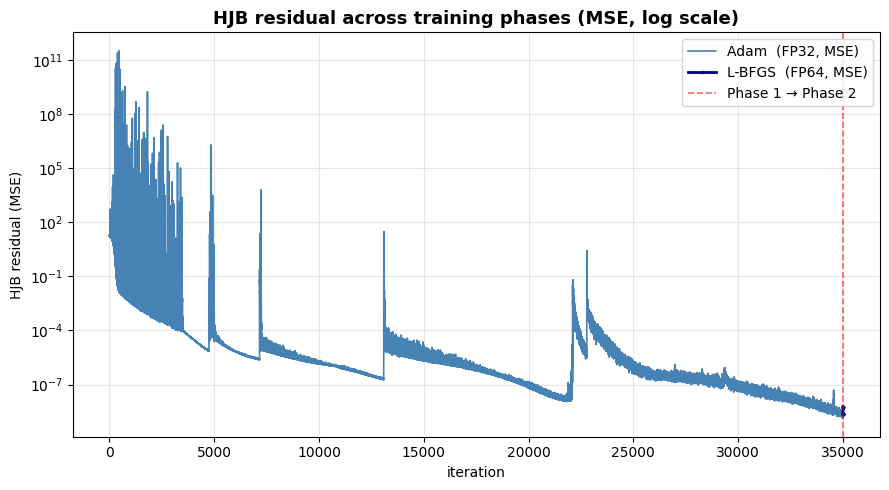


=== Final losses ===
  Phase 1 (Adam)   final HJB (MSE, last epoch) = 2.3423e-09
  Phase 2 (L-BFGS) final HJB (MSE, last iter)  = 2.2371e-09
  L-BFGS reduction factor on HJB               = 1.05e+00×


In [56]:
# =============================================================================
# Cell 7 — Training-loss diagnostics.
# Single-panel log-scale view of the HJB residual across both training phases:
#   Phase 1: Adam (FP32, constant learning rate)
#   Phase 2: L-BFGS (FP64, strong-Wolfe polish on the frozen grid)
# The combined x-axis (iteration) makes the Adam → L-BFGS handoff and the
# polish behaviour visible in one figure.
# =============================================================================

# ---- Build x-axes for the two phases --------------------------------------
ep_adam  = np.arange(1, len(hist_hjb) + 1)
ep_lbfgs = np.arange(len(hist_hjb) + 1,
                     len(hist_hjb) + 1 + len(hist_lbfgs_hjb))

# Only keep LR milestones that actually fired during Adam (skip placeholders
# such as [99999] that were set far past the training horizon).
active_milestones = [ms for ms in LR_MILESTONES if ms < len(hist_hjb)]


# ---- Plot ------------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

ax.semilogy(ep_adam,  hist_hjb,       color='steelblue', lw=1.2,
            label='Adam  (FP32, MSE)')
ax.semilogy(ep_lbfgs, hist_lbfgs_hjb, color='darkblue',  lw=2.0,
            marker='.', ms=3, label='L-BFGS  (FP64, MSE)')
ax.axvline(len(hist_hjb), color='red', linestyle='--', alpha=0.6,
           lw=1.2, label='Phase 1 → Phase 2')
for i, ms in enumerate(active_milestones):
    ax.axvline(ms, color='k', linestyle='--', alpha=0.4,
               label=f'LR drop ep {ms}' if i == 0 else None)

ax.set_title('HJB residual across training phases (MSE, log scale)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('iteration')
ax.set_ylabel('HJB residual (MSE)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('training_loss_LOG.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Numerical summary -----------------------------------------------------
print()
print('=== Final losses ===')
print(f'  Phase 1 (Adam)   final HJB (MSE, last epoch) = {hist_hjb[-1]:.4e}')
print(f'  Phase 2 (L-BFGS) final HJB (MSE, last iter)  = {hist_lbfgs_hjb[-1]:.4e}')
print(f'  L-BFGS reduction factor on HJB               = '
      f'{hist_hjb[-1] / hist_lbfgs_hjb[-1]:.2e}×')

---

## 8. Validation: Value Function on a Grid

Compares the trained network $\widehat V(w, y)$ to the closed-form value
function $V^\star(w, y)$ on a regular grid that extends down to the
boundary $y = 0$.

The cell reports three things:

- **Level diagnostic at $(w, y) = (1, 1)$.** Because the trial solution
  pins the boundary $V(w, 0) = V_{BC}(w)$ exactly, the additive constant
  $K_{cf}$ is the only level degree of freedom and is supposed to be
  recovered from the HJB residual alone. The quantity
  $\widehat K = V^\star(1, 1) - \widehat V(1, 1)$ measures how well that
  recovery worked — $|\widehat K|$ should be small.
- **Hard-BC sanity check.** $\max_w |\widehat V(w, 0) - V_{BC}(w)|$ should
  be at machine-epsilon precision; the architecture guarantees it, and any
  appreciable error here would indicate a bug in the trial solution.
- **2D grid errors.** Max absolute, mean absolute, and relative $L^2$ error
  of $\widehat V$ vs. $V^\star$ over the validation rectangle
  $[W_{\min}, 7] \times [0, 2.2]$, reported as honest unaligned numbers
  (no $K$-shift correction).

=== Level diagnostic at (w, y) = (1, 1) ===
  V_hat(1, 1)  = -0.463114
  V*(1, 1)     = -0.464091    (closed form, post-hoc)
  K_hat        = -0.000978    (level error V* - V_hat)
  |K_hat|      = 9.7760e-04    (level recovery error from HJB alone)

=== Hard-BC sanity check at y = 0 ===
  max  |V_hat(w, 0) - V_BC(w)| = 0.000e+00
  mean |V_hat(w, 0) - V_BC(w)| = 0.000e+00
  (Should be at machine-epsilon precision — guaranteed by construction.)



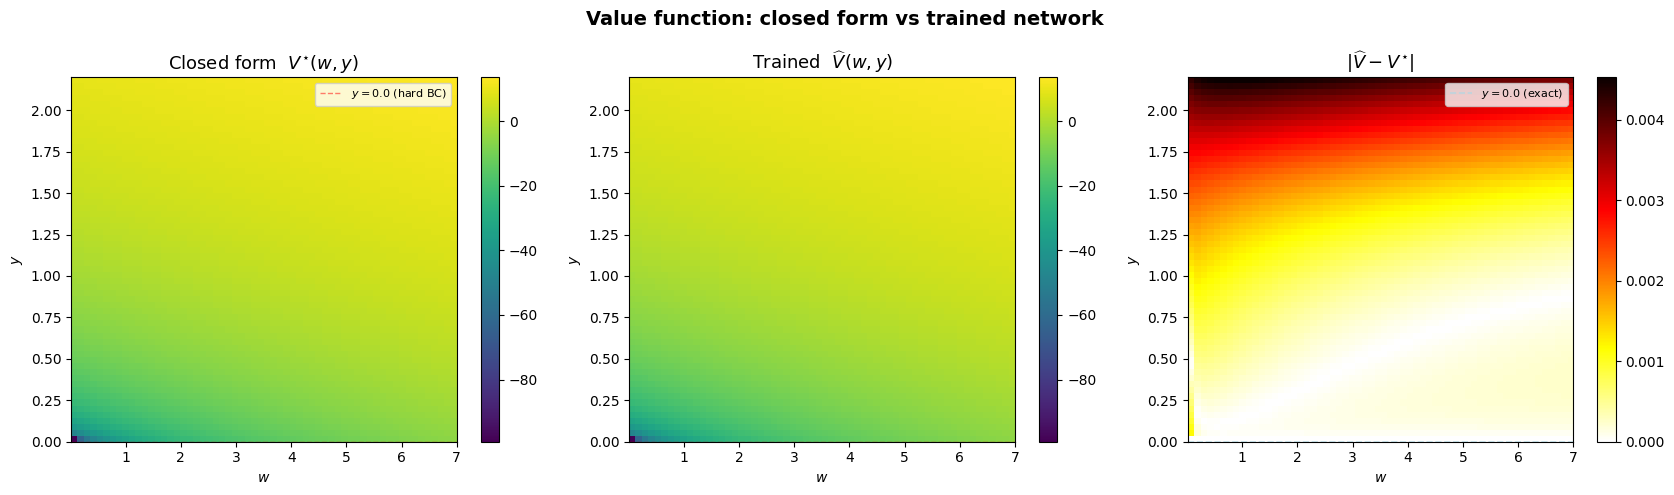

=== 2D grid errors (unaligned, no K-shift correction) ===
  Max absolute  : 0.004533
  Mean absolute : 0.001207
  Relative L²   : 0.0188%    ← primary accuracy metric


In [57]:
# =============================================================================
# Cell 8 — Value-function validation on a 2D grid.
#
# Compares the trained network to the closed-form V* on a regular grid
# extending down to the hard-BC boundary y = 0.
#
# Architecture recap:
#   V_hat(w, y) = (1/δ) log( w + y · softplus(NN(w, y)) ) + K_cf
# At y = 0 the second factor vanishes and V_hat collapses to
#   V_BC(w) = (1/δ) log(w) + K_cf
# exactly, regardless of the network parameters. The closed-form
# V*(w, y) = (1/δ) log(w + φ_e y) + K_cf is used only here, post-hoc,
# for validation — it never enters any training loss.
#
# K_hat is the residual level error at a reference interior point;
# small |K_hat| means the HJB self-consistency alone successfully pinned
# the value-function level without any explicit level-pinning term.
# =============================================================================

net.eval()


# ---- Level diagnostic at reference point (w, y) = (1, 1) ------------------
W_REF_PLOT = torch.tensor([1.0], device=device, dtype=next(net.parameters()).dtype)
Y_REF_PLOT = torch.tensor([1.0], device=device, dtype=next(net.parameters()).dtype)

with torch.no_grad():
    V_hat_at_11 = float(net(W_REF_PLOT, Y_REF_PLOT).cpu())

K_hat = V_true(1.0, 1.0) - V_hat_at_11           # level error: V* - V_hat at (1, 1)

print('=== Level diagnostic at (w, y) = (1, 1) ===')
print(f'  V_hat(1, 1)  = {V_hat_at_11:+.6f}')
print(f'  V*(1, 1)     = {V_true(1.0, 1.0):+.6f}    (closed form, post-hoc)')
print(f'  K_hat        = {K_hat:+.6f}    (level error V* - V_hat)')
print(f'  |K_hat|      = {abs(K_hat):.4e}    (level recovery error from HJB alone)')
print()


# ---- Hard-BC sanity check at the boundary y = 0 ---------------------------
# By construction, at y = 0 the trial solution reduces to V_BC(w);
# this check is an integrity test on the implementation, not a model
# quality metric.
print('=== Hard-BC sanity check at y = 0 ===')
dt_net = next(net.parameters()).dtype
with torch.no_grad():
    w_b = torch.linspace(W_MIN + 0.05, W_MAX - 0.5, 20, device=device, dtype=dt_net)
    y_b = torch.full_like(w_b, Y_MIN)
    V_hat_b   = net(w_b, y_b)
    V_BC_b    = torch.log(w_b) / delta + K_cf
    err_b     = (V_hat_b - V_BC_b).abs()
print(f'  max  |V_hat(w, 0) - V_BC(w)| = {err_b.max().item():.3e}')
print(f'  mean |V_hat(w, 0) - V_BC(w)| = {err_b.mean().item():.3e}')
print(f'  (Should be at machine-epsilon precision — guaranteed by construction.)')
print()


# ---- 2D grid evaluation ---------------------------------------------------
N_GRID = 60
w_grid = np.linspace(W_MIN, 7.0, N_GRID)
y_grid = np.linspace(Y_MIN, 2.2, N_GRID)
WW, YY = np.meshgrid(w_grid, y_grid)

V_cf_grid = V_true(WW, YY)

with torch.no_grad():
    wf = torch.tensor(WW.ravel(), dtype=dt_net, device=device)
    yf = torch.tensor(YY.ravel(), dtype=dt_net, device=device)
    V_nn_raw = net(wf, yf).cpu().numpy().reshape(N_GRID, N_GRID)

err_unaligned = np.abs(V_nn_raw - V_cf_grid)
rel_L2_raw    = np.sqrt(((V_nn_raw - V_cf_grid)**2).mean()) / np.sqrt((V_cf_grid**2).mean())


# ---- 2D heat maps: V*, V_hat, |V_hat - V*| --------------------------------
v_min = min(V_cf_grid.min(), V_nn_raw.min())
v_max = max(V_cf_grid.max(), V_nn_raw.max())

kw   = dict(origin='lower', aspect='auto',
            extent=[w_grid[0], w_grid[-1], y_grid[0], y_grid[-1]])
kw_v = dict(kw, cmap='viridis', vmin=v_min, vmax=v_max)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Closed-form V*
im0 = axes[0].imshow(V_cf_grid, **kw_v)
axes[0].set_title(r'Closed form  $V^{\star}(w, y)$', fontsize=13)
axes[0].set_xlabel('$w$'); axes[0].set_ylabel('$y$')
axes[0].axhline(Y_MIN, color='red', alpha=0.5, lw=1.0, ls='--',
                label=f'$y = {Y_MIN}$ (hard BC)')
axes[0].legend(fontsize=8, loc='upper right')
plt.colorbar(im0, ax=axes[0])

# Trained network V_hat
im1 = axes[1].imshow(V_nn_raw, **kw_v)
axes[1].set_title(r'Trained  $\widehat V(w, y)$', fontsize=13)
axes[1].set_xlabel('$w$'); axes[1].set_ylabel('$y$')
axes[1].axhline(Y_MIN, color='red', alpha=0.5, lw=1.0, ls='--')
plt.colorbar(im1, ax=axes[1])

# Pointwise error
im2 = axes[2].imshow(err_unaligned, **kw, cmap='hot_r')
axes[2].set_title(r'$|\widehat V - V^{\star}|$', fontsize=13)
axes[2].set_xlabel('$w$'); axes[2].set_ylabel('$y$')
axes[2].axhline(Y_MIN, color='lightblue', alpha=0.7, lw=1.2, ls='--',
                label=f'$y = {Y_MIN}$ (exact)')
axes[2].legend(fontsize=8, loc='upper right')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('Value function: closed form vs trained network',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('value_function_LOG.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Numerical summary ----------------------------------------------------
print('=== 2D grid errors (unaligned, no K-shift correction) ===')
print(f'  Max absolute  : {err_unaligned.max():.6f}')
print(f'  Mean absolute : {err_unaligned.mean():.6f}')
print(f'  Relative L²   : {rel_L2_raw:.4%}    ← primary accuracy metric')

---

## 9. Optimal Policies

Optimal consumption and portfolio rules are recovered from the trained
$\widehat V$ via the first-order conditions of the HJB equation:
$$
c^{\star}(w, y) \;=\; \frac{1}{V_w(w, y)},
\qquad
\pi^{\star}(w, y) \;=\;
-\,\frac{V_w(\mu_S - r) \;+\; V_{wy}\,\sigma_S\,\sigma_Y\, y}
       {V_{ww}\,\sigma_S^2}.
$$

**Boundary controls (exact by construction at $y = 0$).** In the
log-utility Merton-with-mortality limit:

- $c^{\star}(w, 0) = \delta\, w$ — log-utility Merton consumption rule.
- $\pi^{\star}(w, 0) = \dfrac{\mu_S - r}{\sigma_S^2}\, w$ — log-utility
  Merton portfolio rule.

Both are exact at $y = 0$ because the hard-BC architecture pins
$V(w, 0) = V_{BC}(w)$ and the FOCs operate on the analytical 1D Merton
derivatives. Away from $y = 0$, the controls are the learned OLG policies.

**Reporting convention.** Consumption error is reported in relative form
because $c^\star > 0$ on the entire validation grid. Portfolio error is
reported in *absolute* form in the second figure, because $\pi^\star$
crosses zero along a diagonal in $(w, y)$-space, where the relative metric
becomes ill-defined even when the absolute error is negligible.


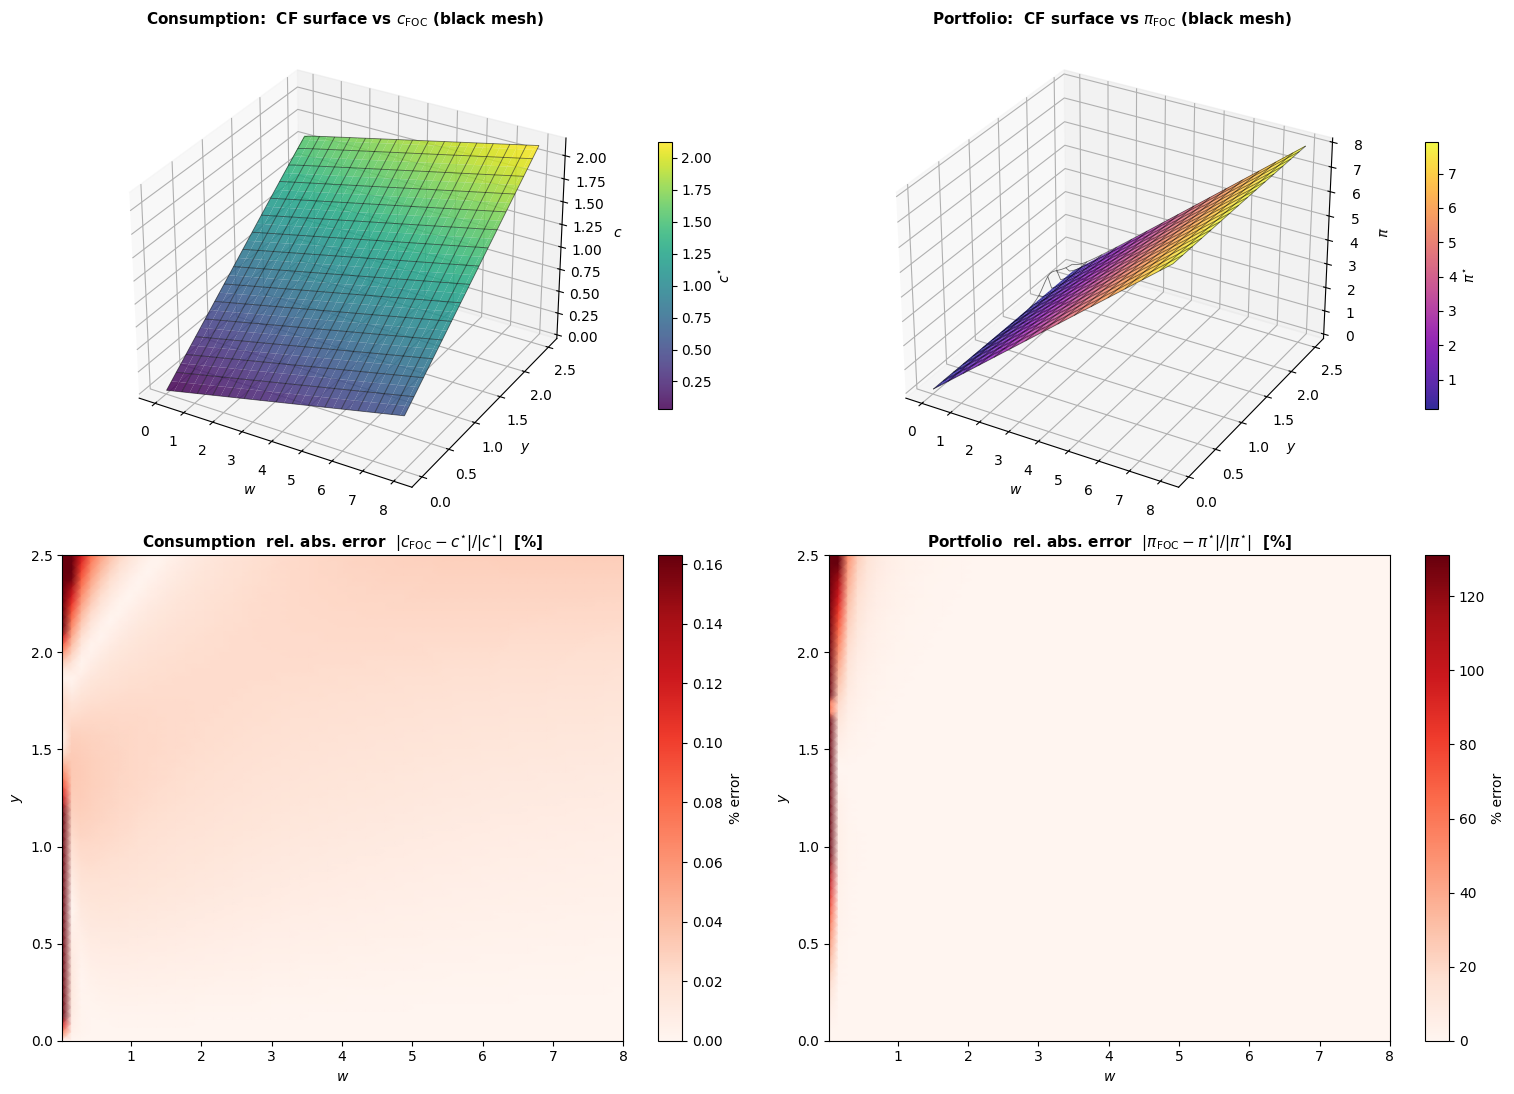

In [58]:
# =============================================================================
# Cell 9.1 — Policies diagnostic (FOC-derived from V).
#
# Recovers c* = 1/V_w and the analytical π-FOC from the trained value
# function, then compares each against its closed-form counterpart on a
# 2D grid.
#
# Layout (2x2):
#   Top row:    3D surfaces — closed form (filled, viridis/plasma) overlaid
#               by the FOC-derived network surface (black wireframe).
#   Bottom row: 2D heatmaps of the relative absolute error for c (left) and π
#               (right). The portfolio panel intentionally still uses
#               relative error here — the absolute-error version is reported
#               separately in the next cell, where it is well-defined across
#               the zero-crossing diagonal of π*.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

# ---- Evaluation grid ------------------------------------------------------
N_GRID = 60
w_lin = torch.linspace(W_MIN + 0.01, W_MAX, N_GRID,
                       device=device, dtype=torch.float64)
y_lin = torch.linspace(Y_MIN, Y_MAX, N_GRID,
                       device=device, dtype=torch.float64)
W_g, Y_g = torch.meshgrid(w_lin, y_lin, indexing='ij')
w_flat = W_g.reshape(-1).requires_grad_(True)
y_flat = Y_g.reshape(-1).requires_grad_(True)


# ---- Network value and autograd derivatives needed for the FOCs -----------
V = net(w_flat, y_flat)
Vw,  = torch.autograd.grad(V,  w_flat, grad_outputs=torch.ones_like(V),  create_graph=True)
Vww, = torch.autograd.grad(Vw, w_flat, grad_outputs=torch.ones_like(Vw), create_graph=True)
Vwy, = torch.autograd.grad(Vw, y_flat, grad_outputs=torch.ones_like(Vw), create_graph=False)

safe_Vw  = Vw.clamp_min(1e-4)            # keeps c = 1/V_w finite
safe_Vww = Vww.clamp_max(-1e-3)          # keeps π well-defined if V briefly non-concave


# ---- FOC-derived policies (log utility: c = 1/V_w; analytical π-FOC) ------
c_FOC_flat  = 1.0 / safe_Vw
pi_FOC_flat = -(Vw * (mu_S - r_cf) + Vwy * sig_S * sig_Y * y_flat) \
              / (safe_Vww * sig_S ** 2)
c_FOC  = c_FOC_flat.detach().cpu().numpy().reshape(N_GRID, N_GRID)
pi_FOC = pi_FOC_flat.detach().cpu().numpy().reshape(N_GRID, N_GRID)


# ---- Closed-form policies (log-utility Merton with labour-income hedge) ---
W_np   = W_g.detach().cpu().numpy()
Y_np   = Y_g.detach().cpu().numpy()
w_eff  = W_np + phi_e * Y_np                                       # effective total wealth
c_star  = delta * w_eff                                            # c*  = δ · w_eff
pi_star = (mu_S - r_cf) / sig_S ** 2 * w_eff - phi_e * Y_np         # π* with hedge term


# ---- Relative absolute errors (%) -----------------------------------------
rel_err_c  = np.abs(c_FOC  - c_star)  / np.abs(c_star)  * 100
rel_err_pi = np.abs(pi_FOC - pi_star) / np.abs(pi_star) * 100


# ---- Figure: 3D surfaces (top) + relative-error heatmaps (bottom) --------
fig = plt.figure(figsize=(15.5, 11.5))

# Top-left: consumption 3D surface + FOC wireframe
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf1 = ax1.plot_surface(W_np, Y_np, c_star, cmap='viridis', alpha=0.85,
                         edgecolor='none', antialiased=True,
                         rstride=2, cstride=2)
ax1.plot_wireframe(W_np, Y_np, c_FOC, color='black', alpha=0.55,
                   linewidth=0.6, rstride=4, cstride=4)
ax1.set_xlabel('$w$'); ax1.set_ylabel('$y$'); ax1.set_zlabel('$c$')
ax1.set_title(r'Consumption:  CF surface vs $c_{\mathrm{FOC}}$ (black mesh)',
              fontsize=11, fontweight='bold')
fig.colorbar(surf1, ax=ax1, shrink=0.55, pad=0.10, label=r'$c^{\star}$')

# Top-right: portfolio 3D surface + FOC wireframe
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
surf2 = ax2.plot_surface(W_np, Y_np, pi_star, cmap='plasma', alpha=0.85,
                         edgecolor='none', antialiased=True,
                         rstride=2, cstride=2)
ax2.plot_wireframe(W_np, Y_np, pi_FOC, color='black', alpha=0.55,
                   linewidth=0.6, rstride=4, cstride=4)
ax2.set_xlabel('$w$'); ax2.set_ylabel('$y$'); ax2.set_zlabel(r'$\pi$')
ax2.set_title(r'Portfolio:  CF surface vs $\pi_{\mathrm{FOC}}$ (black mesh)',
              fontsize=11, fontweight='bold')
fig.colorbar(surf2, ax=ax2, shrink=0.55, pad=0.10, label=r'$\pi^{\star}$')

# Bottom-left: consumption relative-error heatmap
ax3 = fig.add_subplot(2, 2, 3)
vmax_c = np.percentile(rel_err_c, 99)        # clip 99th-percentile outliers for visibility
im3 = ax3.pcolormesh(W_np, Y_np, rel_err_c,
                     cmap='Reds', shading='gouraud', vmin=0, vmax=vmax_c)
ax3.set_xlabel('$w$'); ax3.set_ylabel('$y$')
ax3.set_title(r'Consumption  rel. abs. error  $|c_{\mathrm{FOC}}-c^{\star}|/|c^{\star}|$  [%]',
              fontsize=11, fontweight='bold')
fig.colorbar(im3, ax=ax3, label='% error')

# Bottom-right: portfolio relative-error heatmap (zero-crossing artifact visible)
ax4 = fig.add_subplot(2, 2, 4)
vmax_pi = np.percentile(rel_err_pi, 99)
im4 = ax4.pcolormesh(W_np, Y_np, rel_err_pi,
                     cmap='Reds', shading='gouraud', vmin=0, vmax=vmax_pi)
ax4.set_xlabel('$w$'); ax4.set_ylabel('$y$')
ax4.set_title(r'Portfolio  rel. abs. error  $|\pi_{\mathrm{FOC}}-\pi^{\star}|/|\pi^{\star}|$  [%]',
              fontsize=11, fontweight='bold')
fig.colorbar(im4, ax=ax4, label='% error')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()



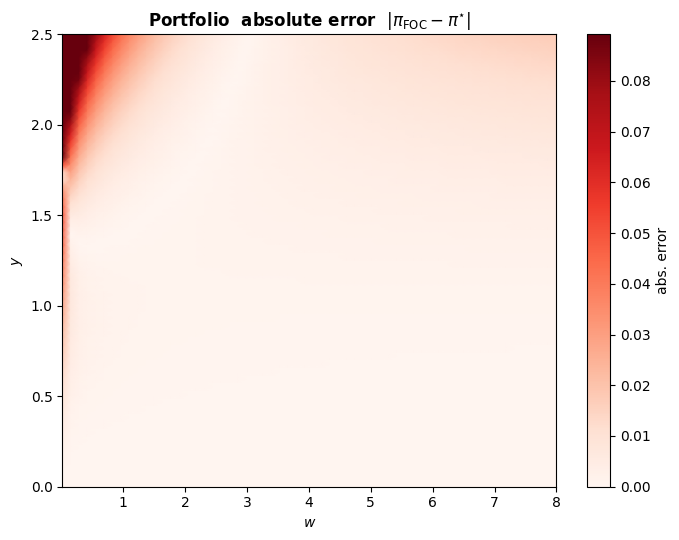

=== Portfolio accuracy summary ===
  max  |π_FOC − π*|         = 0.7320
  mean |π_FOC − π*|         = 0.0068
  max  |π*| on the grid     = 8.0000
  mean |π*| on the grid     = 4.0100
  max abs. error / max |π*| = 9.15%
  relative L²               = 0.80%    ← global accuracy summary


In [59]:
# =============================================================================
# Cell 9.2 — Portfolio absolute-error heatmap (companion to Cell 9).
#
# Reports |π_FOC − π*| in absolute units rather than as a relative %.
# Motivation: π* crosses zero along a diagonal in (w, y)-space, where the
# pointwise relative metric becomes ill-defined even when the absolute error
# is negligible. Absolute error is well-defined everywhere and the only
# quantity that can be honestly compared across the whole validation grid.
#
# Assumes pi_FOC, pi_star, W_np, Y_np already exist in the namespace
# (computed in Cell 9).
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt


# ---- Compute pointwise absolute error -------------------------------------
abs_err_pi = np.abs(pi_FOC - pi_star)


# ---- Heatmap --------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(7, 5.5))
vmax_pi = np.percentile(abs_err_pi, 99)         # clip 99th-percentile outliers
im = ax.pcolormesh(W_np, Y_np, abs_err_pi,
                   cmap='Reds', shading='gouraud', vmin=0, vmax=vmax_pi)
ax.set_xlabel('$w$')
ax.set_ylabel('$y$')
ax.set_title(r'Portfolio  absolute error  $|\pi_{\mathrm{FOC}} - \pi^{\star}|$',
             fontsize=12, fontweight='bold')
fig.colorbar(im, ax=ax, label='abs. error')
plt.tight_layout()
plt.show()


# ---- Numerical summary ----------------------------------------------------
pi_scale_max  = np.abs(pi_star).max()
pi_scale_mean = np.abs(pi_star).mean()
rel_L2        = np.sqrt((abs_err_pi ** 2).mean()) / np.sqrt((pi_star ** 2).mean())

print('=== Portfolio accuracy summary ===')
print(f'  max  |π_FOC − π*|         = {abs_err_pi.max():.4f}')
print(f'  mean |π_FOC − π*|         = {abs_err_pi.mean():.4f}')
print(f'  max  |π*| on the grid     = {pi_scale_max:.4f}')
print(f'  mean |π*| on the grid     = {pi_scale_mean:.4f}')
print(f'  max abs. error / max |π*| = {abs_err_pi.max() / pi_scale_max:.2%}')
print(f'  relative L²               = {rel_L2:.2%}    ← global accuracy summary')

---

## 10. Wealth-to-Consumption Ratio Diagnostic

The wealth-to-consumption ratio
$$
\frac{w}{c^{\star}(w, y)}
\;=\;
\frac{w}{\delta\,(w + \varphi_e\,y)}
$$
is reported as a derived diagnostic — distinct from comparing $c^\star$
directly because the ratio strips out the level of $c$ and isolates the
intertemporal-substitution structure.

**Boundary anchor (log-utility Merton limit).** At $y = 0$ the ratio
collapses to the classical Merton constant
$$
\frac{w}{c^{\star}(w, 0)} \;=\; \frac{w}{\delta\,w} \;=\; \frac{1}{\delta},
$$
independent of $w$. Because the trial solution enforces the hard
boundary condition $V(w, 0) = V_{BC}(w)$, the FOC-derived ratio
$w / c_{\mathrm{FOC}}(w, 0)$ should reproduce $1/\delta$ to
machine-epsilon precision — this is a strong second-order test of the
boundary architecture (sensitive to $V_w$, not just to $V$).

**Reporting.** Left panel: 3D surface of the closed-form ratio overlaid by
the FOC-derived network ratio (black wireframe). Right panel: 2D
heatmap of the relative absolute error. The bottom row of the printed
summary verifies the $1/\delta$ anchor explicitly.

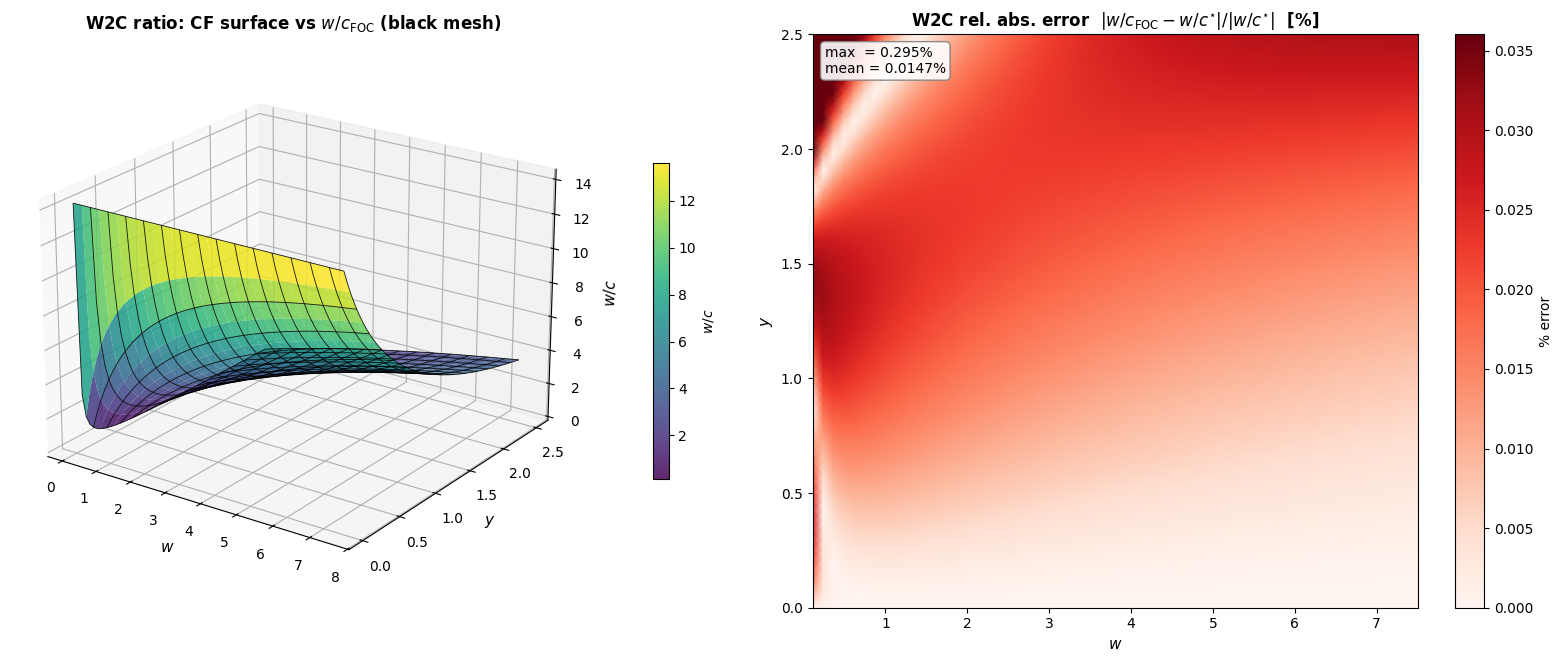


=== W2C ratio agreement (full grid, FOC-derived from V) ===
  max abs error      = 0.0011
  mean abs error     = 0.0004
  max rel error      = 0.295%
  mean rel error     = 0.0147%
  relative L²        = 0.0085%    ← global accuracy summary

=== Hard-BC anchor at y = 0.0 (log-utility Merton limit) ===
  Expected w/c       = 1/δ = 14.28571
  Mean w/c (FOC)     = 14.28571
  Max |w/c - 1/δ|    = 1.77636e-15


In [60]:
# =============================================================================
# Cell 10 — Wealth-to-consumption ratio diagnostic.
#
# Compares the closed-form ratio
#     w / c*(w, y) = w / [δ (w + φ_e y)]
# to the FOC-derived ratio
#     w / c_FOC(w, y) = w · V_w(w, y)
# on a 2D grid, with a hard-BC sanity check at y = 0 (the ratio must equal
# the Merton constant 1/δ exactly there).
#
# Side benefit: the ratio diagnostic isolates the intertemporal-substitution
# structure from the level of c, and is sensitive to V_w accuracy (not just
# V itself).
# =============================================================================
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401  (registers '3d' projection)
import numpy as np
import matplotlib.pyplot as plt

dt_net = next(net.parameters()).dtype
net.eval()


# ---- FOC-derived consumption helper ---------------------------------------
def c_FOC_array(w, y):
    """Return c = 1/V_w on numpy inputs via autograd through the trained net.
    Applies the same V_w clamp safeguard used during training."""
    w_t = torch.as_tensor(w, dtype=dt_net, device=device).clone().requires_grad_(True)
    y_t = torch.as_tensor(y, dtype=dt_net, device=device).clone().requires_grad_(True)
    _, Vw, _, _, _, _, _, _ = compute_all_derivatives(net, w_t, y_t)
    safe_Vw = Vw.clamp_min(1e-4)
    c = 1.0 / safe_Vw
    return c.detach().cpu().numpy()


# ---- Evaluation grid ------------------------------------------------------
N_2D = 60
w_2d = np.linspace(W_MIN + 0.1, W_MAX - 0.5, N_2D)
y_2d = np.linspace(Y_MIN, Y_MAX, N_2D)
WW_2d, YY_2d = np.meshgrid(w_2d, y_2d)


# ---- Closed-form and FOC-derived W2C ratios -------------------------------
# Closed form: c*(w, y) = δ (w + φ_e y),  so  w / c* = w / [δ (w + φ_e y)].
C_cf_2d = delta * (WW_2d + phi_e * YY_2d)
W2C_cf  = WW_2d / C_cf_2d

# FOC-derived: c_FOC = 1 / V_w, evaluated through the trained network.
C_nn_2d = c_FOC_array(WW_2d.ravel(), YY_2d.ravel()).reshape(N_2D, N_2D)
W2C_nn  = WW_2d / C_nn_2d


# ---- Relative absolute error (%) ------------------------------------------
rel_err_w2c = np.abs(W2C_nn - W2C_cf) / np.abs(W2C_cf) * 100
vmax_w2c    = np.percentile(rel_err_w2c, 99)        # clip 99th-percentile outliers


# ---- Figure: 3D surface + wireframe (left), 2D heatmap (right) ------------
fig = plt.figure(figsize=(16, 7))

# Left: 3D surface (closed form) overlaid by FOC-derived wireframe
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(WW_2d, YY_2d, W2C_cf, cmap='viridis',
                        edgecolor='none', alpha=0.85, antialiased=True,
                        rstride=2, cstride=2)
ax1.plot_wireframe(WW_2d, YY_2d, W2C_nn, color='black', linewidth=0.6,
                   rstride=4, cstride=4, alpha=0.9)
ax1.set_xlabel('$w$', fontsize=11)
ax1.set_ylabel('$y$', fontsize=11)
ax1.set_zlabel('$w / c$', fontsize=11)
ax1.set_title(r'W2C ratio: CF surface vs $w / c_{\mathrm{FOC}}$ (black mesh)',
              fontsize=12, fontweight='bold')
ax1.view_init(elev=22, azim=-55)
fig.colorbar(surf, ax=ax1, shrink=0.55, pad=0.10, label=r'$w / c$')

# Right: 2D heatmap of relative error
ax2 = fig.add_subplot(1, 2, 2)
im2 = ax2.pcolormesh(WW_2d, YY_2d, rel_err_w2c,
                     cmap='Reds', shading='gouraud', vmin=0, vmax=vmax_w2c)
ax2.set_xlabel('$w$', fontsize=11)
ax2.set_ylabel('$y$', fontsize=11)
ax2.set_title(r'W2C rel. abs. error  $|w/c_{\mathrm{FOC}} - w/c^{\star}| / |w/c^{\star}|$  [%]',
              fontsize=12, fontweight='bold')
fig.colorbar(im2, ax=ax2, label='% error')
ax2.text(0.02, 0.98,
         f'max  = {rel_err_w2c.max():.3f}%\nmean = {rel_err_w2c.mean():.4f}%',
         transform=ax2.transAxes, va='top', ha='left', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white',
                   alpha=0.9, edgecolor='gray'))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('w2c_ratio_LOG.png', dpi=150, bbox_inches='tight')
plt.show()


# ---- Numerical summary ----------------------------------------------------
err_w2c    = np.abs(W2C_nn - W2C_cf)
rel_L2_w2c = np.sqrt(((W2C_nn - W2C_cf) ** 2).mean()) \
             / np.sqrt((W2C_cf ** 2).mean())

print()
print('=== W2C ratio agreement (full grid, FOC-derived from V) ===')
print(f'  max abs error      = {err_w2c.max():.4f}')
print(f'  mean abs error     = {err_w2c.mean():.4f}')
print(f'  max rel error      = {rel_err_w2c.max():.3f}%')
print(f'  mean rel error     = {rel_err_w2c.mean():.4f}%')
print(f'  relative L²        = {rel_L2_w2c:.4%}    ← global accuracy summary')

print()
print(f'=== Hard-BC anchor at y = {Y_MIN} (log-utility Merton limit) ===')
print(f'  Expected w/c       = 1/δ = {1.0/delta:.5f}')
print(f'  Mean w/c (FOC)     = {W2C_nn[0, :].mean():.5f}')
print(f'  Max |w/c - 1/δ|    = {np.abs(W2C_nn[0, :] - 1.0/delta).max():.5e}')